This notebook described the PTRPC analysis - CD45KO 

# Load Libraries

In [31]:
suppressPackageStartupMessages({
    library(gdata)
    library(singlecellmethods)
    library(matrixStats)
    library(data.table)
    library(viridis)
    #library(seaborn)
    library(RColorBrewer)
    library(ComplexHeatmap)
    library(Matrix)
    library(harmony)
    library(uwot)
    library(irlba)
    library(Seurat)
    library(factoextra)
    library(presto) 
    source("DNA_filtering_Functions.R")
    source("misc_funcs.R")
    source("utils.R")
    library(tidyverse)
    library(ggpubr)
    library(ggridges)
    library(ggrepel)
})

# Load All libraries. Skip steps below

In [32]:
FlowMatrix <- read_csv("FlowMatrixFinal.csv")

Rows: 6144 Columns: 23
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (12): Well_ID, DNA_cell, RNA_cell, Experiment_Index, Plate, Edited_Index...
dbl (11): PB_CD81, BV605_CD45, BV750_CD45, SSC, FSC, FITC_CD45, PE_CD81, PEC...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [33]:
#Load Meta RNA
meta <- read_csv("meta.csv")

Rows: 6144 Columns: 13
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (10): plate, cell, PlateLabel, Condition, DNA_Barcode, ADT_Barcode, sgRN...
dbl  (3): nUMI, nGenes, pctMito

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [34]:
#Import RNA - processed separately 
exprs <- readMM(file = "exprs.mtx")
colnames(exprs) <- read_csv("exprs_colnames.csv") %>% with(x)
rownames(exprs) <- read_csv("exprs_rownames.csv") %>% with(x)

New names:
• `` -> `...1`
Rows: 6144 Columns: 2
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (1): x
dbl (1): ...1

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 36591 Columns: 2
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (1): x
dbl (1): ...1

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [35]:
#Import ADT
meta_adt_filt <- read_csv("meta_ADT_filt.csv")
counts_adt_filt <- readMM(file = "counts_ADT_filt.mtx")
colnames(counts_adt_filt) <- read_csv("colnames_counts_ADT_filt.csv") %>% with(x)
rownames(counts_adt_filt) <- read_csv("rownames_counts_ADT_filt.csv") %>% with(x)


Rows: 6038 Columns: 12
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (10): plate, cell_adt, PlateLabel, Condition, RNA_Barcode, DNA_Barcode, ...
dbl  (2): nUMI, nGenes

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 6144 Columns: 2
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (1): x
dbl (1): ...1

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 154 Columns: 2
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────

In [36]:
#Add DNA
meta_DNA <- read_csv("CD45_RPL8_TYK2_Meta.csv")
alleles_DNA <- read_csv("alleles_DNA.csv")
#Add Meta 
alleles_DNA_meta<- inner_join(alleles_DNA, meta_DNA)

Rows: 16 Columns: 8
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (8): PlateLabel, Condition, RNA_Barcode, DNA_Barcode, ADT_Barcode, sgRNA...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 8389 Columns: 8
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (3): DNA_Barcode, Well_ID, Aligned_Sequence
dbl (5): n_deleted, n_inserted, n_mutated, #Reads, %Reads

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Joining with `by = join_by(DNA_Barcode)`


# Subset DNA - CD45

In [37]:
#subset for analysis
CD45_alleles_DNA <- filter(alleles_DNA_meta, Condition == "CD45")

In [38]:
CD45_alleles_DNA <- rename(CD45_alleles_DNA, "Barcode_DNA" = DNA_Barcode)

# Genomic DNA Amplicon Analysis

In [39]:
DNAfiles = "Analysis/Alleles"

In [11]:
#Alleles Function for Import - Updated- Fixed Naming to Automate and Changed to Capture the top 10 alleles per cell. 
AllelesFunction <- 
function (filepath, number_of_alleles = 10, folder_name="Alleles") #Filepath is the folder with all the allele tables. 
{
    files <- list.files(path = filepath, pattern = ".txt$", full.names = T, 
        recursive = T) 
    
    matrix <- suppressMessages({
        suppressWarnings({
            lapply(files, read_tsv, n_max = number_of_alleles, col_select = c(1, 
                5, 6, 7, 8, 9))
        })
    })
    names(matrix) <- lapply(files, FUN = 
      function(x) { 
          paste0(substr(x, str_locate(x, paste0(folder_name, "/"))[2]+1, str_locate(x, "/CRISPRessoBatch_on_batch")[1]-1), #modified for Full
                            "_", 
                             substr(x, str_locate(x, "CRISPResso_on_([A-Z])(\\d)")[2]-1, str_locate(x, "/Alleles_frequency_table.txt")[1]-1))})
    
    matrix <- bind_rows(matrix, .id = "Plate_Well")
    return(matrix)
}

In [47]:
#Upload all Alleles
alleles_DNA <- AllelesFunction(DNAfiles, folder_name="Alleles")

In [58]:
#add meta data
alleles_DNA <- alleles_DNA %>% separate(Plate_Well, into = c("DNA_Barcode", "Well_ID")) %>% 
inner_join(meta_DNA)

Joining with `by = join_by(DNA_Barcode)`


In [59]:
write_csv(alleles_DNA, "alleles_DNA_updated.csv")

In [40]:
alleles_DNA <- read_csv("alleles_DNA_updated.csv")

Rows: 34706 Columns: 15
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (10): DNA_Barcode, Well_ID, Aligned_Sequence, PlateLabel, Condition, RNA...
dbl  (5): n_deleted, n_inserted, n_mutated, #Reads, %Reads

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [41]:
CD45_alleles <- filter(alleles_DNA, Condition == "CD45")

In [42]:
CD45_alleles <- rename(CD45_alleles, Barcode_DNA = DNA_Barcode)

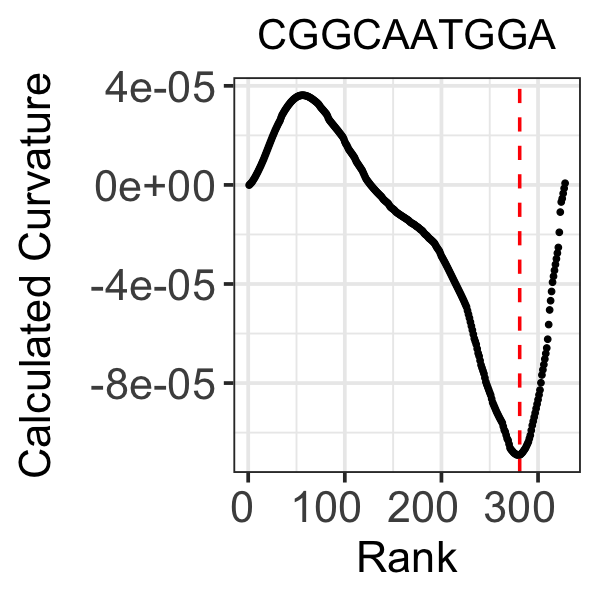

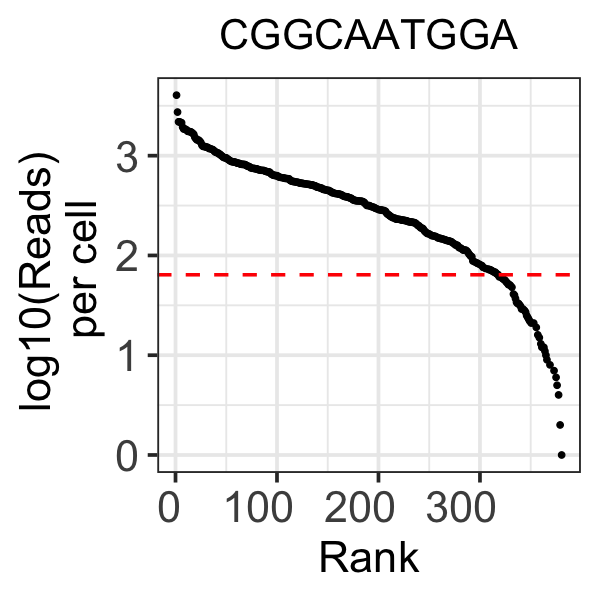

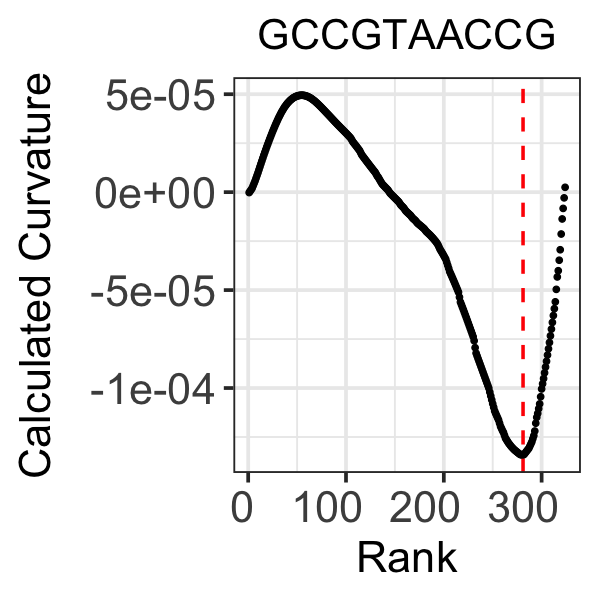

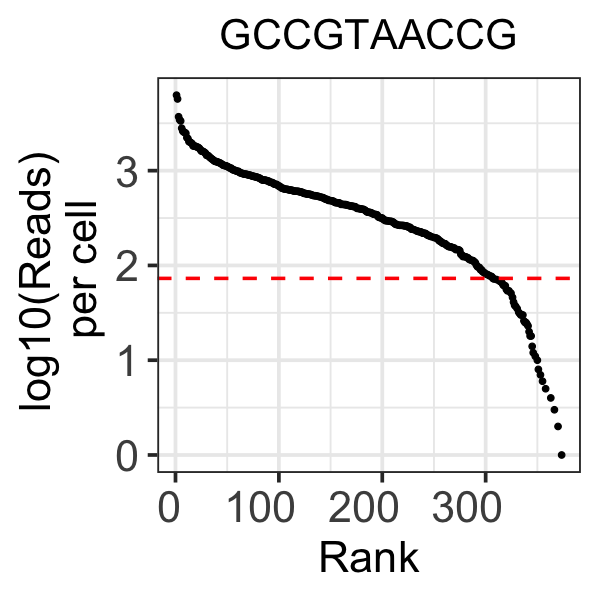

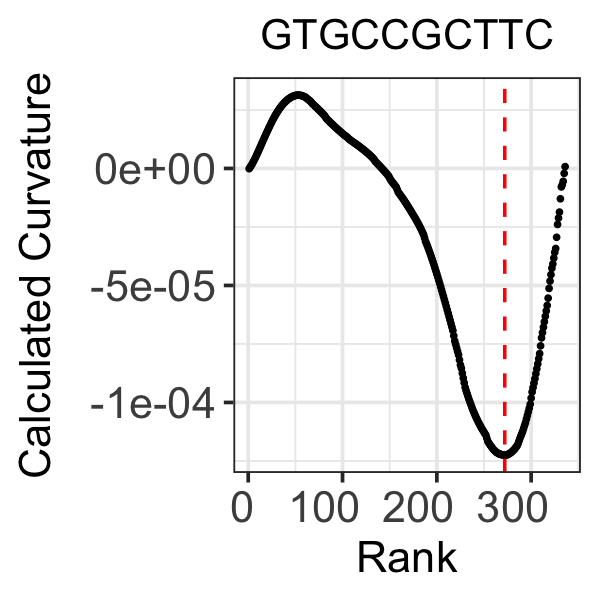

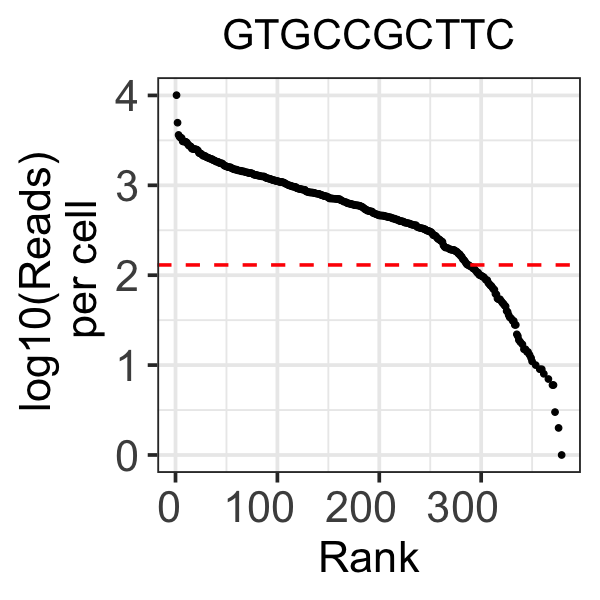

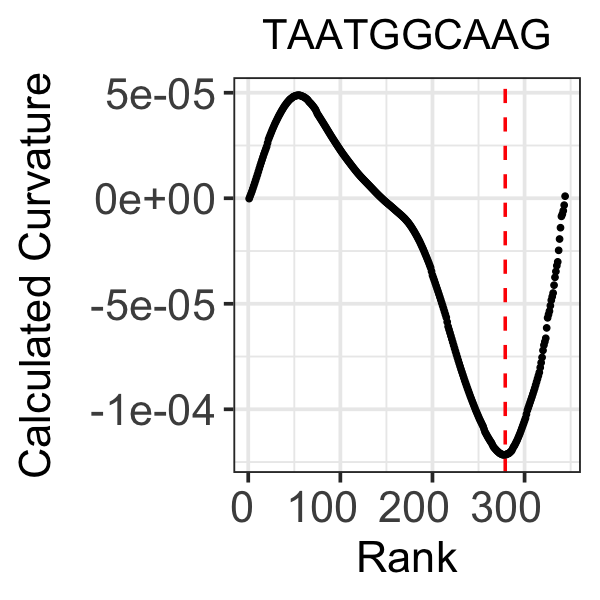

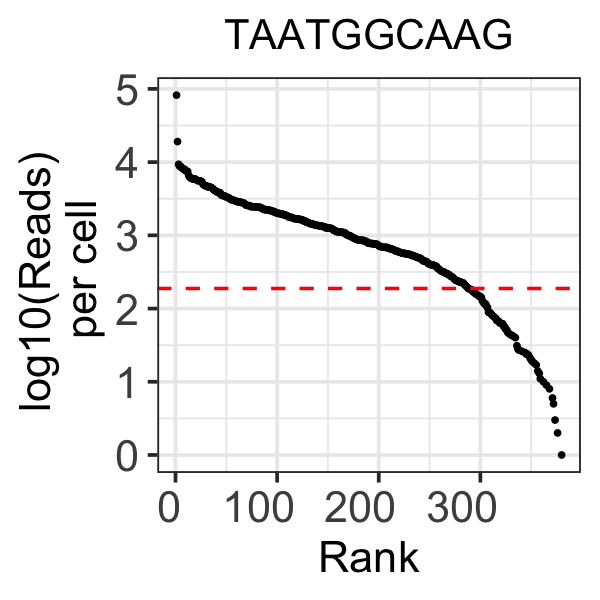

In [43]:
fig.size(5,5)
CD45_alleles <- Filtering_Cells_Read(CD45_alleles)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


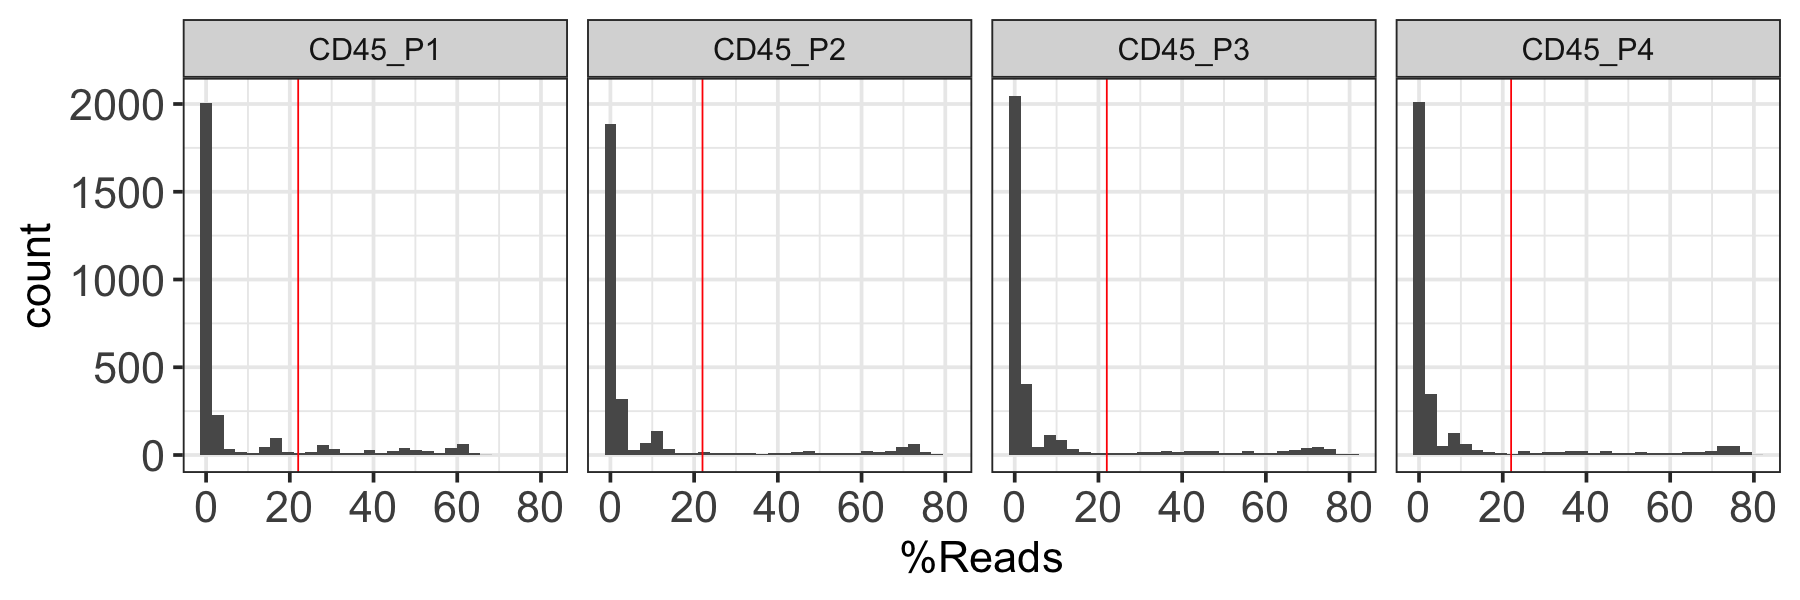

In [44]:
fig.size(5,15)
#Define a cutoff
CD45_alleles %>% 
    ggplot(aes(`%Reads`)) + geom_histogram() + 
    theme_gy() + geom_vline(xintercept = 22, color = "red") + facet_grid(~PlateLabel)

In [45]:
source("/Users/bagtq9/Desktop/Box Sync/2017 - Raychaudhuri Lab/Lab Documents/scRNA-DNA GSK/Experiments/UpdatedExperiments/DNA_filtering_Functions.R")

In [46]:
CD45_filt <- CD45_alleles %>% Filtering_Alleles(cutoff=22)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


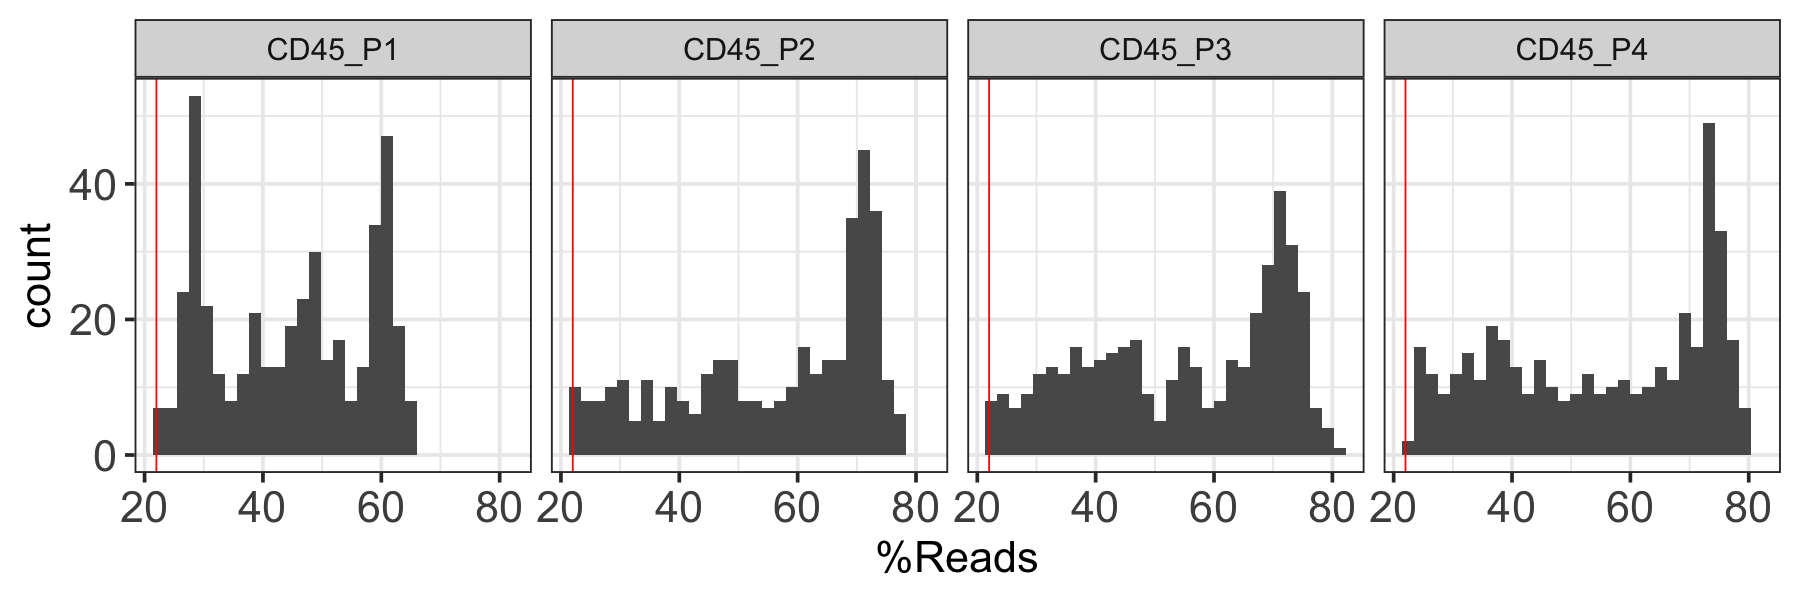

In [47]:
fig.size(5,15)
#Define a cutoff
CD45_filt %>% 
    ggplot(aes(`%Reads`)) + geom_histogram() + 
    theme_gy() + geom_vline(xintercept = 22, color = "red") + facet_grid(~PlateLabel)

In [48]:
#Match lenghts of Ref and Allele
CD45_filt <- mutate(CD45_filt, 
                               Aligned_Sequence = str_trunc(Aligned_Sequence, 180, "right", ""))
#Fix length from P7
CD45_filt<- CD45_filt %>% 
    mutate("Aligned_Sequence" = str_trunc(Aligned_Sequence, 150, "left", ellipsis = "")) %>% 
    mutate("Reference"= str_trunc(Reference, 150, "left", ellipsis = ""))%>% 
    mutate("Aligned_Sequence" = str_trunc(Aligned_Sequence, 40, "right", ellipsis = "")) %>% 
    mutate("Reference"= str_trunc(Reference, 40, "right", ellipsis = ""))

In [49]:
## Remove alleles found in less than 5 cells. 
CD45_filt <- CD45_filt  %>% add_count(name = "AlleleCount", Aligned_Sequence) %>% filter(AlleleCount >5)

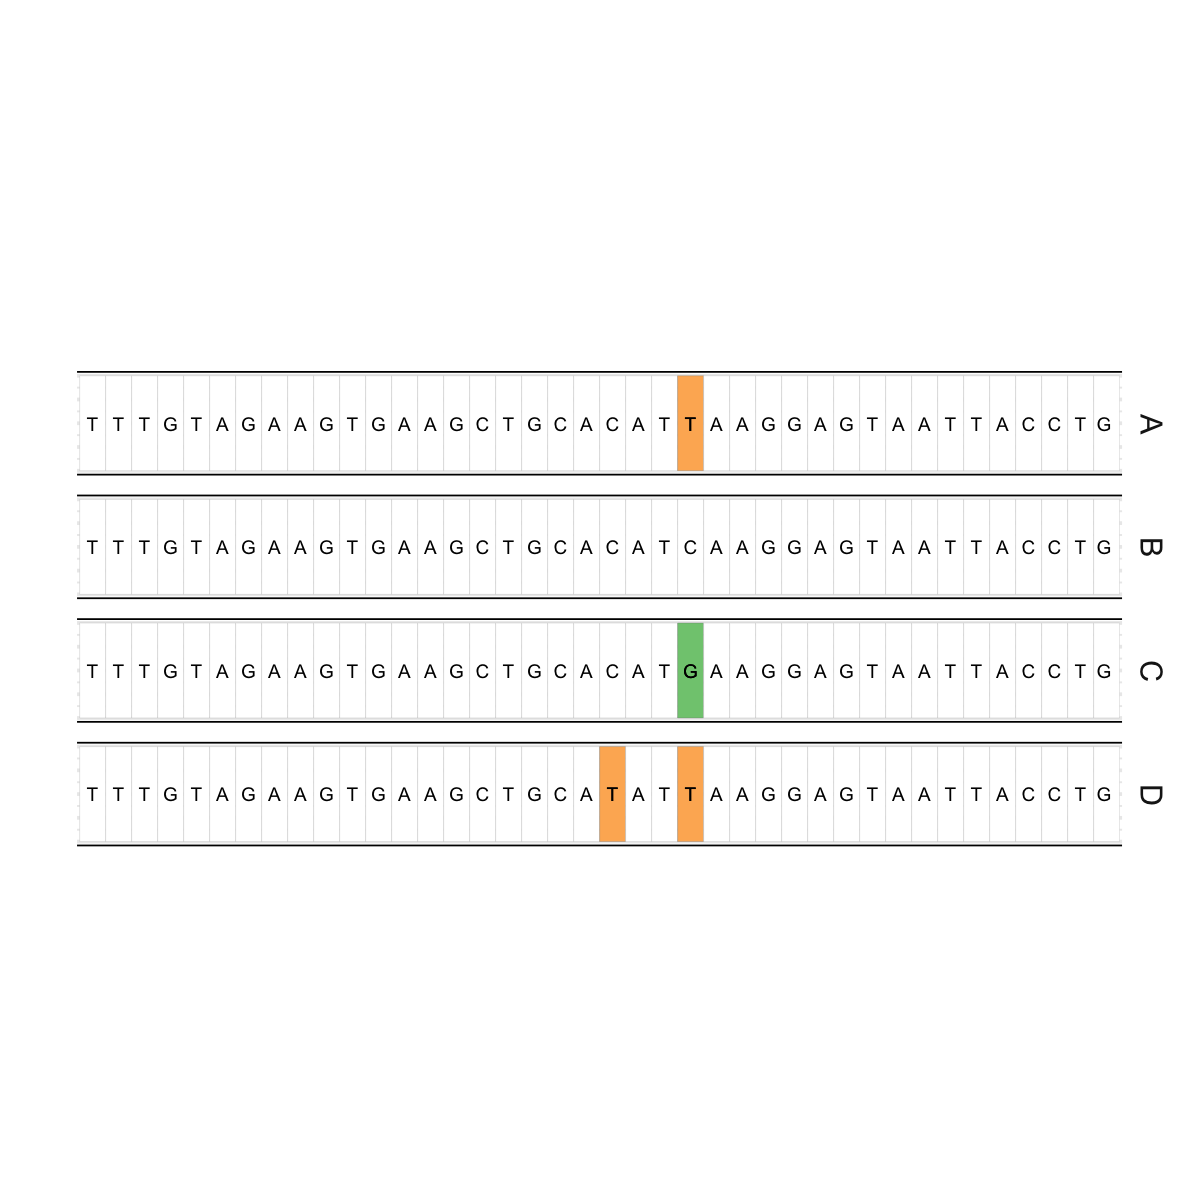

In [50]:
CD45_filt %>% Plotting_Alleles

In [51]:
CD45_gen <- Genotyping_Cells(CD45_filt)

# Quality Control

## RNA filtering on nGenes and nUMI (500, 1000)

In [ ]:
# QC figures

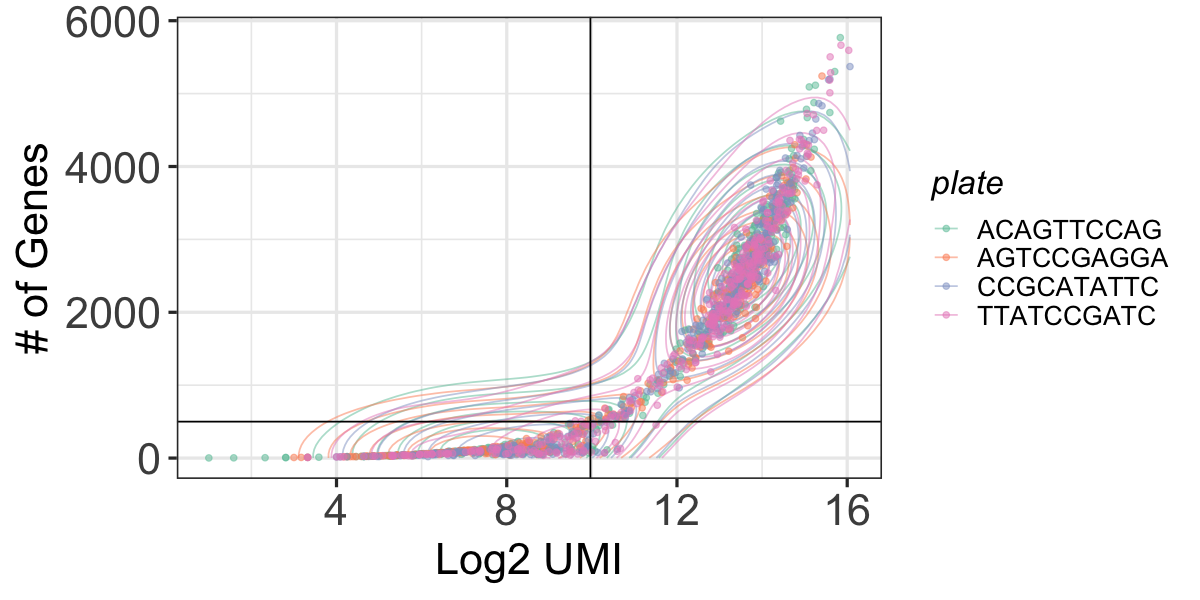

In [52]:
fig.size(5, 10)
ggplot(filter(meta, Condition == "CD45")) +
    geom_density_2d(aes(x=log2(nUMI), y=nGenes, color = plate), alpha = 0.5)+ 
    geom_point(aes(x=log2(nUMI), y=nGenes, color = plate), alpha = 0.5) +
    theme_gy(20) + ylab("# of Genes") + 
    xlab("Log2 UMI") + scale_color_brewer(palette = "Set2") + 
   geom_vline(xintercept = log2(1000))+ 
geom_hline(yintercept = 500)
    

In [53]:
nCells = rowSums(exprs > 0)
gene_qc = data.frame(nCells = nCells %>% sort %>% rev, rank = seq(1, length(nCells)))

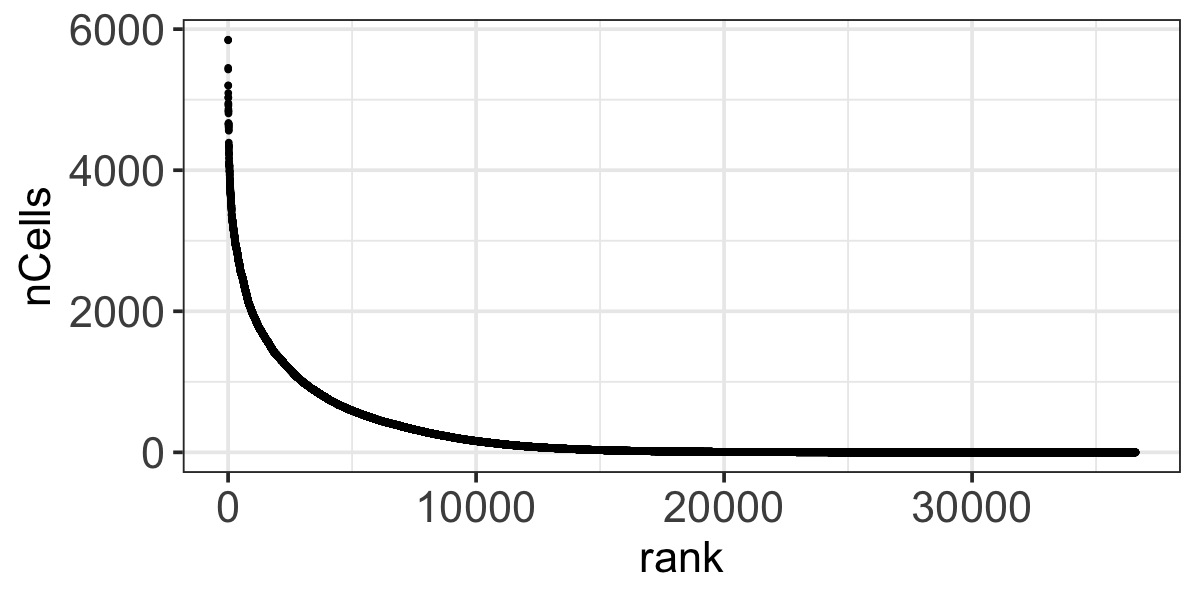

In [54]:
ggplot(gene_qc)+
    geom_point(aes(x = rank, y = nCells))+
    theme_gy()

In [55]:
nUMI_thresh =  1000 #5000 #40
nGene_thresh = 500
pctMito_thresh = 0.1
ncell_thresh = 10

filt_exprs = exprs[rownames(gene_qc %>% filter(nCells > ncell_thresh)), 
                   (meta %>% filter(nUMI > nUMI_thresh, 
                                               nGenes > nGene_thresh, 
                                               pctMito < pctMito_thresh) %>% with(cell))]
filt_meta = filter(meta, cell %in% colnames(filt_exprs))

## ADT QC

In [57]:
counts_ADT_filt <- counts_adt_filt

In [58]:
meta_ADT_filt <- meta_adt_filt

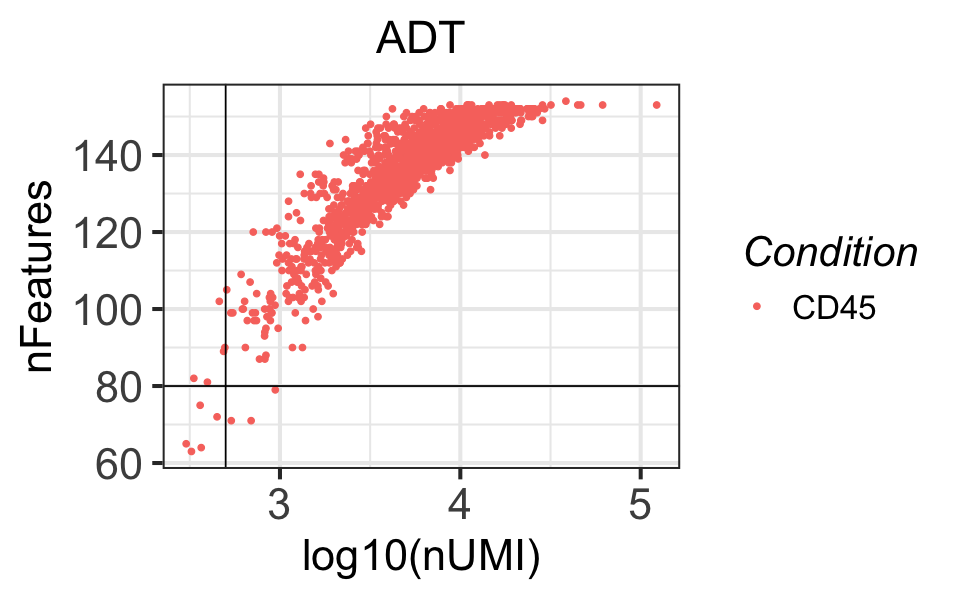

In [59]:
fig.size(5, 8)
ggplot(meta_ADT_filt %>% filter(Condition == "CD45"))+
    geom_point(aes(x=log10(nUMI), y=nGenes, col = Condition))+
    theme_gy(25)+
    # geom_vline(xintercept = log10(1e3))+
    ggtitle('ADT')+
    ylab('nFeatures')+
    geom_vline(xintercept = log10(500))+
    geom_hline(yintercept = 80)

In [60]:
meta_ADT_filt <- meta_ADT_filt %>% filter(nUMI >= 500 & nGenes >= 80)

In [61]:
counts_ADT_filt<- counts_ADT_filt[,(meta_ADT_filt$cell)]

# Pre-process expression data

In [62]:
#Add rownames
rownames(meta_ADT_filt) <- meta_ADT_filt$cell
rownames(filt_meta) <- filt_meta$cell

Warning message:
“Setting row names on a tibble is deprecated.”
Warning message:
“Setting row names on a tibble is deprecated.”


In [63]:
#select only CD45 data for RNA
filt_meta_CD45 <- filter(filt_meta, Condition == "CD45")
filt_exprs_CD45 <- filt_exprs[,filt_meta_CD45$cell]

In [64]:
#select only CD45 data for ADT
meta_ADT_filt_CD45 <- filter(meta_ADT_filt, Condition == "CD45")
counts_ADT_filt_CD45 <- counts_ADT_filt[,meta_ADT_filt_CD45$cell]

In [65]:
### Pre-process based on metadata conditions
scale_exprs_CD45 = process_rna(filt_exprs_CD45, 
                               filt_meta_CD45)

'as(<dgTMatrix>, "dgCMatrix")' is deprecated.
Use 'as(., "CsparseMatrix")' instead.
See help("Deprecated") and help("Matrix-deprecated").



In [66]:
scale_exprs_CD45 %>% dim

[1] 3000  901

# Merging of Flow & DNA & RNAmeta & ADTmeta data

In [67]:
CD45Plots <- CD45_filt %>% select(Barcode_DNA, Well_ID, plate_well) %>% unique %>% inner_join(CD45_gen) %>% 
inner_join(
    FlowMatrix %>% mutate(FlowMatrix,plate_well = paste0(DNA_Barcode, Well_ID))
    ) %>%
inner_join(select(
    meta_ADT_filt_CD45, 
    cell, nUMI, nGenes)) %>% 
inner_join(select(
    filt_meta_CD45, 
    cell, nUMI, nGenes), by = "cell") %>%
add_count(AllelicGenotype, name = "genotype_count") %>% filter(Plate != "P1")
# Plate 1 had bad DNA data, clearly problematic. #Needs to be removed from all assays in this experiment. Not included in final meta data. 
# Control cells act as ground truth. Along with genotype distribution. 

Joining with `by = join_by(plate_well)`
Joining with `by = join_by(Well_ID, plate_well)`
Joining with `by = join_by(cell)`


In [522]:
#export this table
write_csv(CD45Plots, "CD45Plots_Updated.csv")

In [253]:
CD45PlotsOLD <- read_csv("CD45Plots.csv")

Rows: 628 Columns: 32
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (15): DNA_Barcode, Well_ID, Alleles, Reference, PlateLabel, Condition, R...
dbl (17): genotype, PB_CD81, BV605_CD45, BV750_CD45, SSC, FSC, FITC_CD45, PE...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# UMAPs

In [68]:
set.seed(120)

In [ ]:
### Run PCA/Harmony/UMAP based on metadata conditions

## RNA

Warning message:
“Warning: The parameters do_pca and npcs are deprecated. They will be ignored for this function call and please remove parameters do_pca and npcs and pass to harmony cell_embeddings directly.
This warning is displayed once per session.”
Warning message:
“Warning: The parameter max.iter.harmony is replaced with parameter max_iter. It will be ignored for this function call and please use parameter max_iter in future function calls.
This warning is displayed once per session.”
Warning message:
“Warning: The parameter max.iter.cluster is deprecated. It will be ignored for this function call and please remove parameter max.iter.cluster in future function calls. Advanced users can set value of parameter max.iter.cluster by using parameter .options and function harmony_options().
This warning is displayed once per session.”
Warning message:
“Warning: The parameter epsilon.cluster is deprecated. It will be ignored for this function call and please remove parameter epsilon.clus

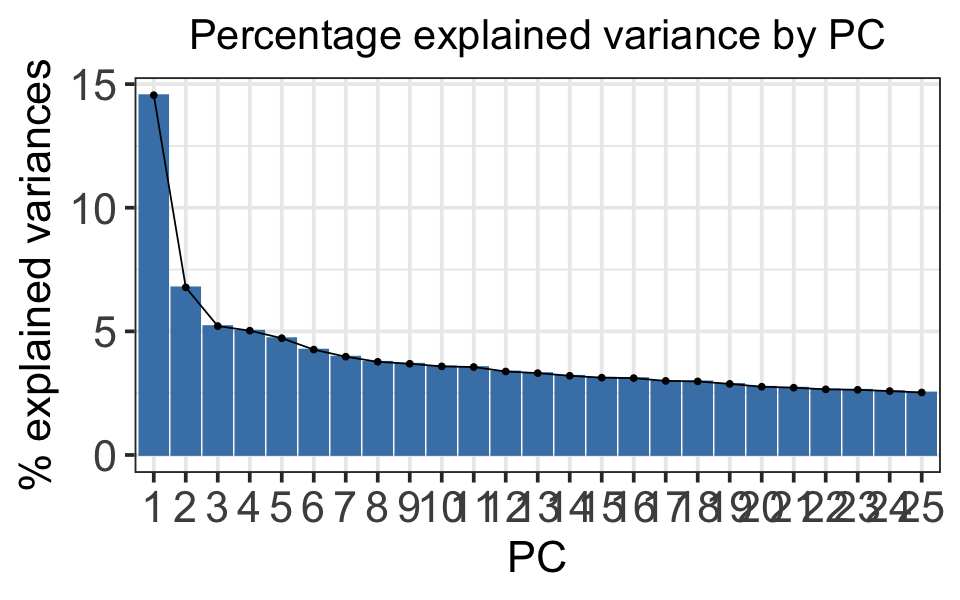

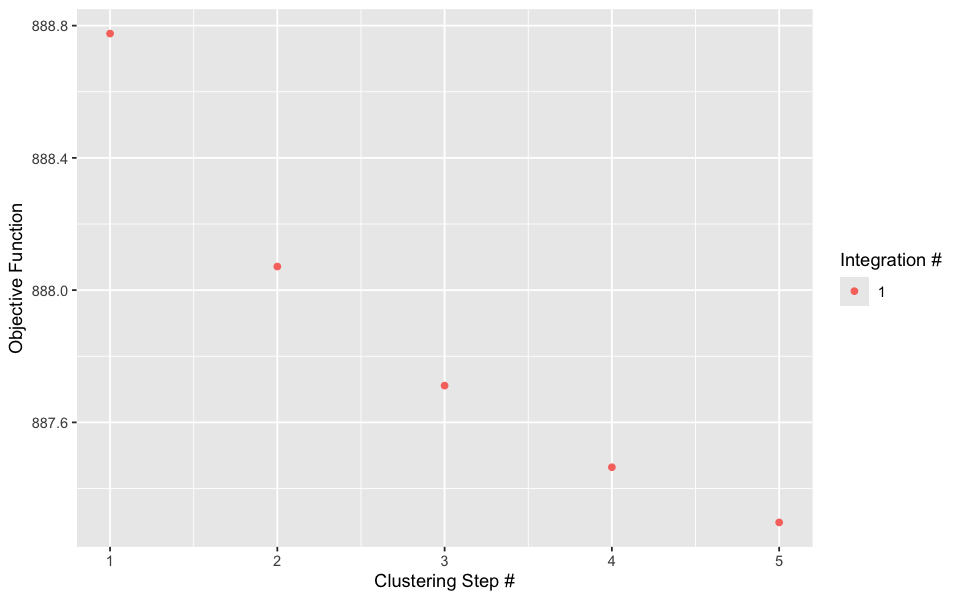

In [69]:
# Figure out overlapping cells with ADT, RNA, and DNA. Use that subset to cluster. 
filt_meta_CD45 <- filter(filt_meta, cell %in% CD45Plots$cell)
meta_umap_CD45 = pca_umap(scale_exprs_CD45[, filt_meta_CD45$cell], filt_meta_CD45, 
                          harmony_var = c('PlateLabel'))

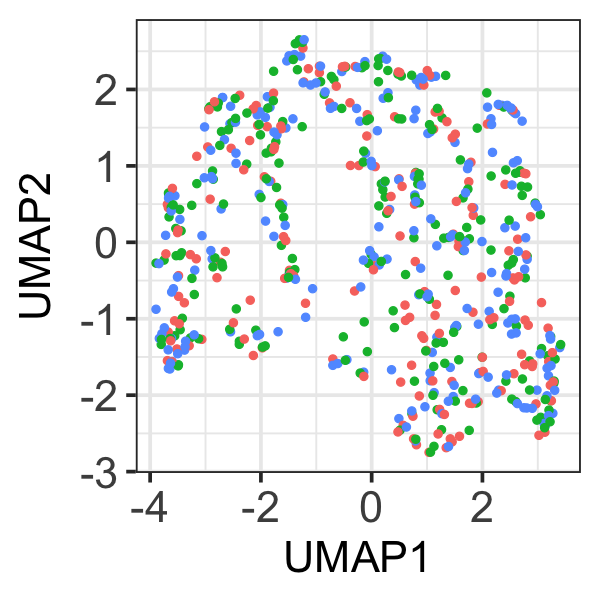

In [70]:
fig.size(5, 5)
ggplot(meta_umap_CD45 %>% sample_n(nrow(meta_umap_CD45)))+
    geom_point(aes(x = UMAP1, y = UMAP2, col = PlateLabel), size = 2)+
    theme_gy()+
theme(legend.position = "none")

In [71]:
scale_exprs <- normalizeData(filt_exprs, method = "log")

Joining with `by = join_by(cell)`


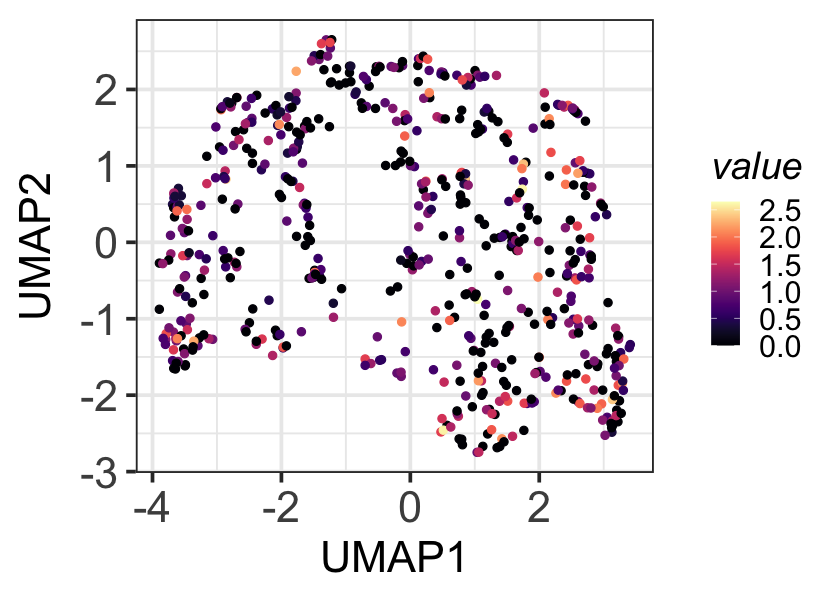

In [72]:
#CD45 gene expression differences?
fig.size(5,7)
scale_exprs["PTPRC",meta_umap_CD45$cell] %>% as_tibble(rownames = "cell")  %>% 
inner_join(meta_umap_CD45) %>% 

    ggplot()+
    geom_point(aes(x = UMAP1, y = UMAP2, col = value), size = 2)+
    theme_gy()+
     scale_color_viridis(option = "magma")+ 
theme(legend.position = "right")


## ADT

In [73]:
meta_adt_filt_CD45 <- filter(meta_ADT_filt, cell %in% CD45Plots$cell)

In [74]:
## filter adts to remove Igs ... causing problems. 
counts_ADT_filt <- counts_ADT_filt[!grepl(rownames(counts_ADT_filt), pattern = "Ig"),]

In [75]:
counts_ADT_filt <- counts_ADT_filt[,meta_adt_filt_CD45$cell]

Warning message:
“package ‘EnvStats’ was built under R version 4.3.3”

Attaching package: ‘EnvStats’


The following object is masked from ‘package:matrixStats’:

    iqr


The following objects are masked from ‘package:stats’:

    predict, predict.lm




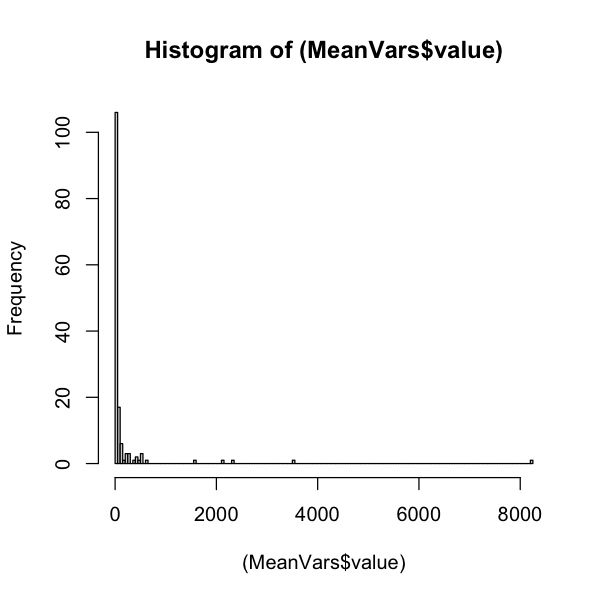

In [77]:
fig.size(5,5)
## Need to work out some kind of ADT filtering strategy as the ADTs fail to converge. Some assumptions are broken. 
## Variance is too high to estimate changes for mean expression. 
#Calcuate Variance over Mean (too high indicates that the expression is low and variance is too high)
library(EnvStats) #Load outlier library
MeanVars <- (rowVars(as.matrix(counts_ADT_filt))/ rowMeans(counts_ADT_filt)  ) %>% as_tibble(rownames = "gene") %>% arrange(-value)
hist((MeanVars$value), breaks = length(MeanVars$value)) #estimate outliers based on distributions

In [80]:
#set K
outliers <- rosnerTest(MeanVars$value, k = 5) %>% with(all.stats) %>% with(Obs.Num) #identify outliers with rosnerTest
genes <- MeanVars$gene[-outliers] # remove outliers

In [81]:
counts_ADT_filt_CD45 <- counts_ADT_filt[genes,]

In [82]:
scale_adt_CD45 = process_adt(counts_ADT_filt_CD45, 
                        meta_ADT_filt_CD45)

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony converged after 1 iterations

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’



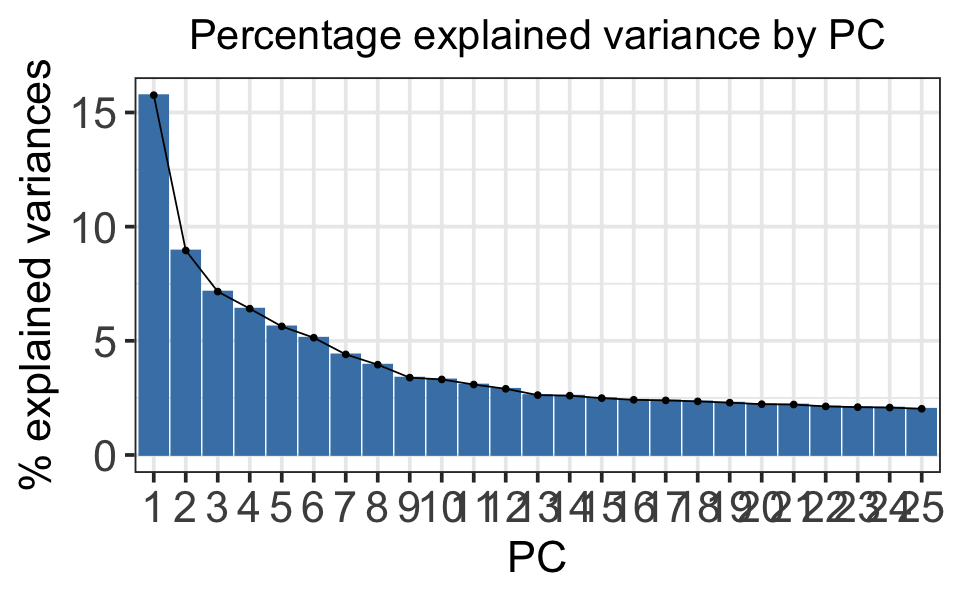

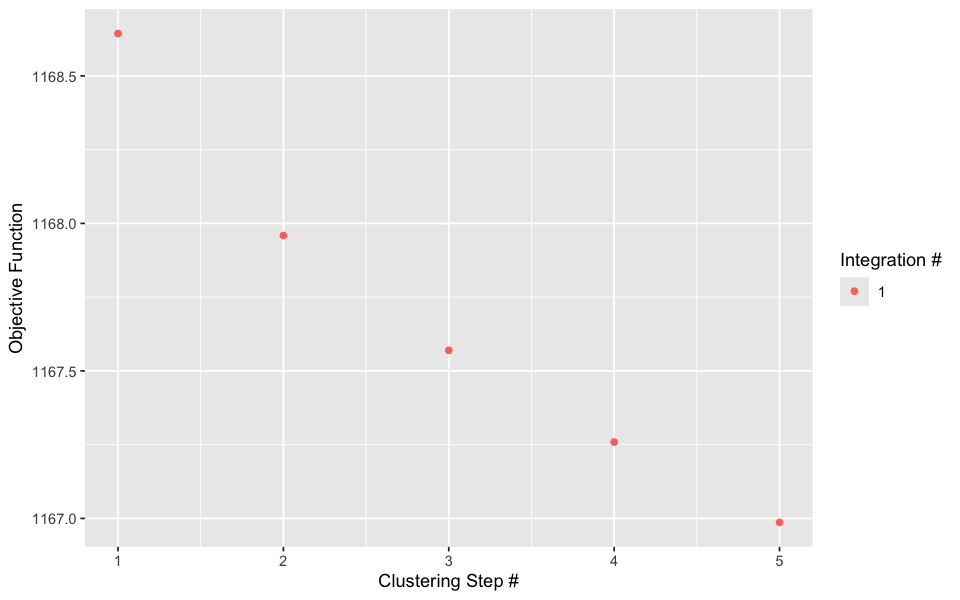

In [83]:
meta_umap_adt_CD45 <- pca_umap(scale_adt_CD45, meta_adt_filt_CD45, harmony_var = "PlateLabel")

In [85]:
scale_adt <- scale_adt_CD45

Joining with `by = join_by(cell)`


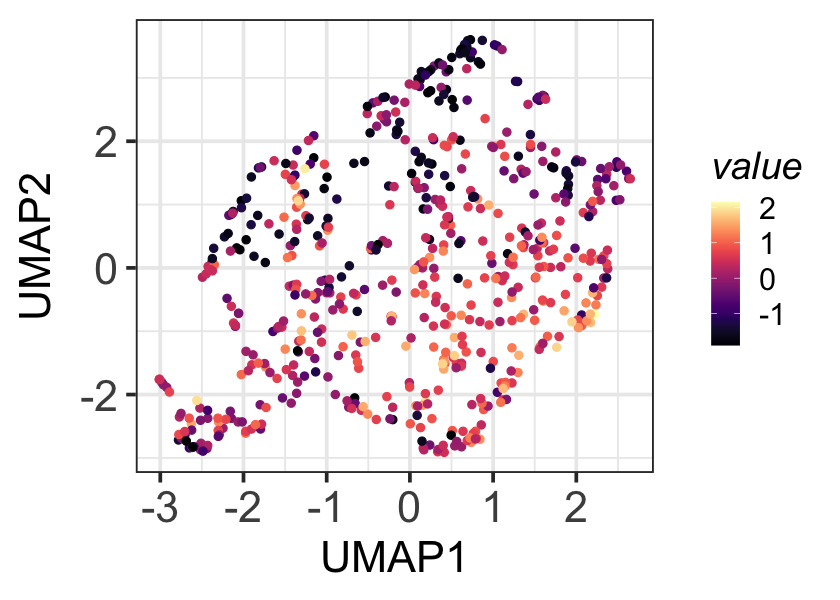

In [86]:
fig.size(5,7)
scale_adt["CD45",meta_umap_adt_CD45$cell] %>% as_tibble(rownames = "cell")  %>% 
inner_join(meta_umap_adt_CD45) %>% 

    ggplot()+
    geom_point(aes(x = UMAP1, y = UMAP2, col = value), size = 2)+
    theme_gy()+
     scale_color_viridis(option = "magma")+ 
theme(legend.position = "right")


# Clustering + DGE

## RNA

In [88]:
meta_umap_CD45.clust = do_cluster(meta_umap_CD45, resolution_list = seq(0.05, 0.5, 0.05))

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 618
Number of edges: 20830

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9500
Number of communities: 1
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 618
Number of edges: 20830

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9000
Number of communities: 1
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 618
Number of edges: 20830

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8500
Number of communities: 1
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 618
Number of edges: 20830

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8233
Number of communities: 2
Elapsed time: 0 seconds
Modularity Optimizer version

In [89]:
table(meta_umap_CD45.clust$`res.0.2`)


  0   1 
350 268 

In [90]:
meta_umap_CD45.clust$cluster = meta_umap_CD45.clust$`res.0.2`

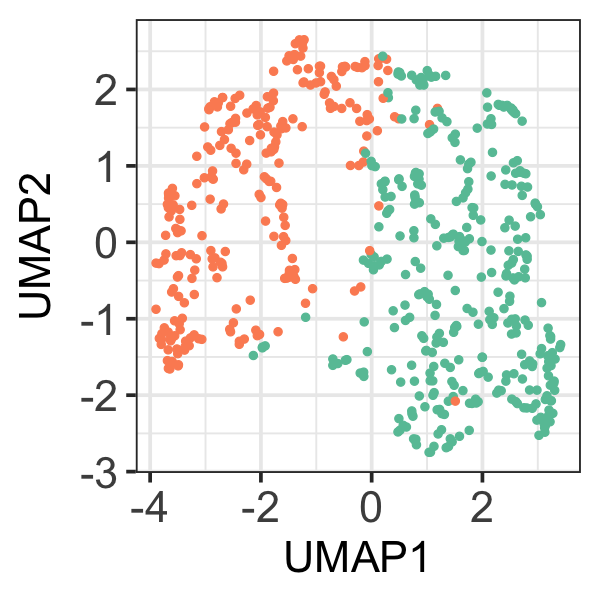

In [91]:
fig.size(5, 5)
ggplot(meta_umap_CD45.clust[sample(rownames(meta_umap_CD45.clust)), ])+
    geom_point(aes(x= UMAP1, y = UMAP2, col = cluster), size = 2)+
theme_gy() + 
theme(legend.position = "none") + 
scale_color_brewer(palette = "Set2")

In [94]:
df<-meta_umap_CD45.clust %>% arrange(cluster)
dge_CD45 = wilcoxauc(scale_exprs_CD45[,df$cell], df$cluster)
var_genes_CD45 = top_markers(dge_CD45, 5) %>% head(5) %>% select(-rank) %>% 
                        unlist %>% unique 
cmax = abs(scale_exprs_CD45[var_genes_CD45,df$cell ]) %>% unlist %>% max #%>% quantile(.995)

# Data frame with column annotations.
mat_col <- data.frame(cluster = df$cluster)
rownames(mat_col) <- rownames(df)


# Sort dendogram
mat_cluster_cols <- hclust(dist(t(scale_exprs_CD45[var_genes_CD45, df$cell])))
mat_cluster_cols <- sort_hclust(mat_cluster_cols)
mat_cluster_rows <- sort_hclust(hclust(dist(scale_exprs_CD45[var_genes_CD45,df$cell ])))

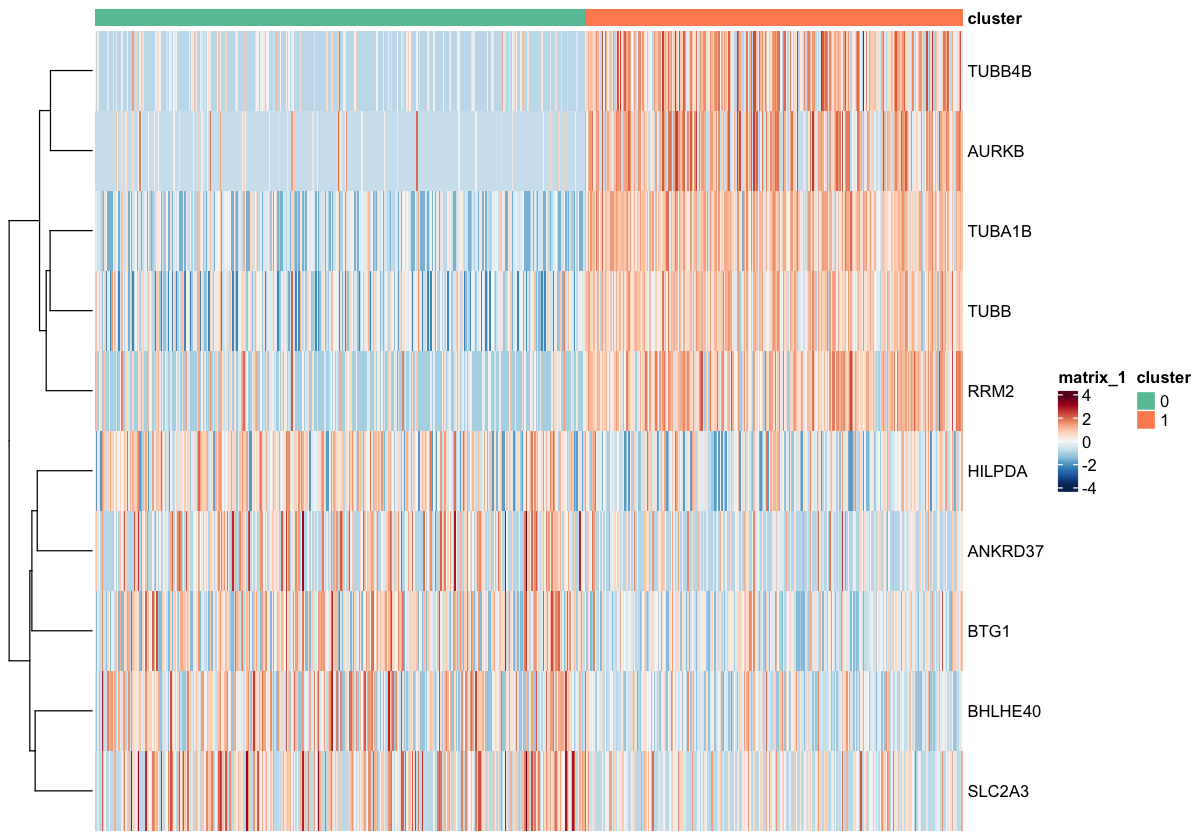

In [95]:
fig.size(7, 10)
pheatmap(scale_exprs_CD45[c(var_genes_CD45), df$cell],
         breaks = seq(-cmax, cmax, length.out = 100),
        color = colorRampPalette(brewer.pal(11, "RdBu"))(100) %>% rev,
        show_colnames = FALSE,
         annotation_col = mat_col, 
         fontsize = 10,
         cluster_cols = F,
         annotation_colors = list(cluster = c(
                                  `0` = "#66C2A5", 
                                  `1` = "#FC8D62" 
            #                      `2` = "#8DA0CB"
                                     )),
        cluster_rows = mat_cluster_rows,

        )

## ADT

In [96]:
meta_umap_adt_CD45.clust = do_cluster(meta_umap_adt_CD45, resolution_list = seq(0.1, 1, 0.1))

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 618
Number of edges: 22194

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9000
Number of communities: 1
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 618
Number of edges: 22194

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8000
Number of communities: 1
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 618
Number of edges: 22194

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7125
Number of communities: 2
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 618
Number of edges: 22194

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.6614
Number of communities: 3
Elapsed time: 0 seconds
Modularity Optimizer version

In [103]:
table(meta_umap_adt_CD45.clust$'res.0.4')


  0   1   2 
292 225 101 

In [104]:
meta_umap_adt_CD45.clust$cluster = meta_umap_adt_CD45.clust$`res.0.4`

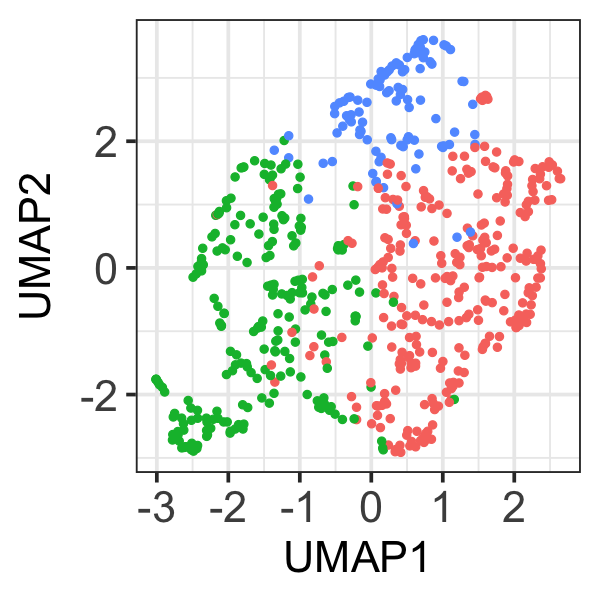

In [105]:
fig.size(5, 5)
ggplot(meta_umap_adt_CD45.clust[sample(rownames(meta_umap_adt_CD45.clust)), ])+
    geom_point(aes(x= UMAP1, y = UMAP2, col = cluster), size = 2)+
  theme_gy() + 
theme(legend.position = "none")

Rows: 384 Columns: 2
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Well_ID, RNA_cell

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Joining with `by = join_by(Well_ID)`
Joining with `by = join_by(plate_well)`
Joining with `by = join_by(cell)`


plate_well,cell,genotype,AllelicGenotype,plate,cell_adt,PlateLabel,Condition,RNA_Barcode,DNA_Barcode,⋯,res.0.2,res.0.3,res.0.4,res.0.5,res.0.6,res.0.7,res.0.8,res.0.9,res.1,cluster
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
CGGCAATGGAA1,AACATCTCTGTGAC_CCGCATATTC,TTTGTAGAAGTGAAGCTGCACATTAAGGAGTAATTACCTG,A,CCTTGTTAAT,AACATCTCTGTGAC_CCTTGTTAAT,CD45_P3,CD45,CCGCATATTC,CGGCAATGGA,⋯,0,0,2,2,2,2,2,6,6,2
CGGCAATGGAA10,AAGCTCCACTCAGA_CCGCATATTC,TTTGTAGAAGTGAAGCTGCACATCAAGGAGTAATTACCTG,B,CCTTGTTAAT,AAGCTCCACTCAGA_CCTTGTTAAT,CD45_P3,CD45,CCGCATATTC,CGGCAATGGA,⋯,0,0,0,0,1,1,1,4,4,0
CGGCAATGGAA13,AATGCCGTTACACA_CCGCATATTC,TTTGTAGAAGTGAAGCTGCACATCAAGGAGTAATTACCTG_TTTGTAGAAGTGAAGCTGCACATTAAGGAGTAATTACCTG,AB,CCTTGTTAAT,AATGCCGTTACACA_CCTTGTTAAT,CD45_P3,CD45,CCGCATATTC,CGGCAATGGA,⋯,0,0,0,0,2,2,2,6,6,0
CGGCAATGGAA14,AATGCGCATACAGT_CCGCATATTC,TTTGTAGAAGTGAAGCTGCACATCAAGGAGTAATTACCTG,B,CCTTGTTAAT,AATGCGCATACAGT_CCTTGTTAAT,CD45_P3,CD45,CCGCATATTC,CGGCAATGGA,⋯,0,0,1,1,0,0,0,0,0,1
CGGCAATGGAA16,AATGTCATCGCGCT_CCGCATATTC,TTTGTAGAAGTGAAGCTGCACATCAAGGAGTAATTACCTG_TTTGTAGAAGTGAAGCTGCACATTAAGGAGTAATTACCTG,AB,CCTTGTTAAT,AATGTCATCGCGCT_CCTTGTTAAT,CD45_P3,CD45,CCGCATATTC,CGGCAATGGA,⋯,0,0,0,0,1,3,3,1,1,0
CGGCAATGGAA18,ACAAGAGACTCCAA_CCGCATATTC,TTTGTAGAAGTGAAGCTGCACATTAAGGAGTAATTACCTG,A,CCTTGTTAAT,ACAAGAGACTCCAA_CCTTGTTAAT,CD45_P3,CD45,CCGCATATTC,CGGCAATGGA,⋯,0,0,1,1,0,0,0,0,0,1
CGGCAATGGAA21,ACACTCAGCTGTAA_CCGCATATTC,TTTGTAGAAGTGAAGCTGCACATTAAGGAGTAATTACCTG,A,CCTTGTTAAT,ACACTCAGCTGTAA_CCTTGTTAAT,CD45_P3,CD45,CCGCATATTC,CGGCAATGGA,⋯,0,0,2,2,2,2,2,2,2,2
CGGCAATGGAA22,ACAGAGAACCGCTC_CCGCATATTC,TTTGTAGAAGTGAAGCTGCACATTAAGGAGTAATTACCTG,A,CCTTGTTAAT,ACAGAGAACCGCTC_CCTTGTTAAT,CD45_P3,CD45,CCGCATATTC,CGGCAATGGA,⋯,0,0,1,1,0,0,0,0,0,1
CGGCAATGGAA23,ACAGCTATGATCGT_CCGCATATTC,TTTGTAGAAGTGAAGCTGCACATCAAGGAGTAATTACCTG,B,CCTTGTTAAT,ACAGCTATGATCGT_CCTTGTTAAT,CD45_P3,CD45,CCGCATATTC,CGGCAATGGA,⋯,0,0,0,0,1,1,1,3,3,0


Rows: 384 Columns: 2
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Well_ID, RNA_cell

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Joining with `by = join_by(Well_ID)`
Joining with `by = join_by(plate_well)`
Joining with `by = join_by(cell)`


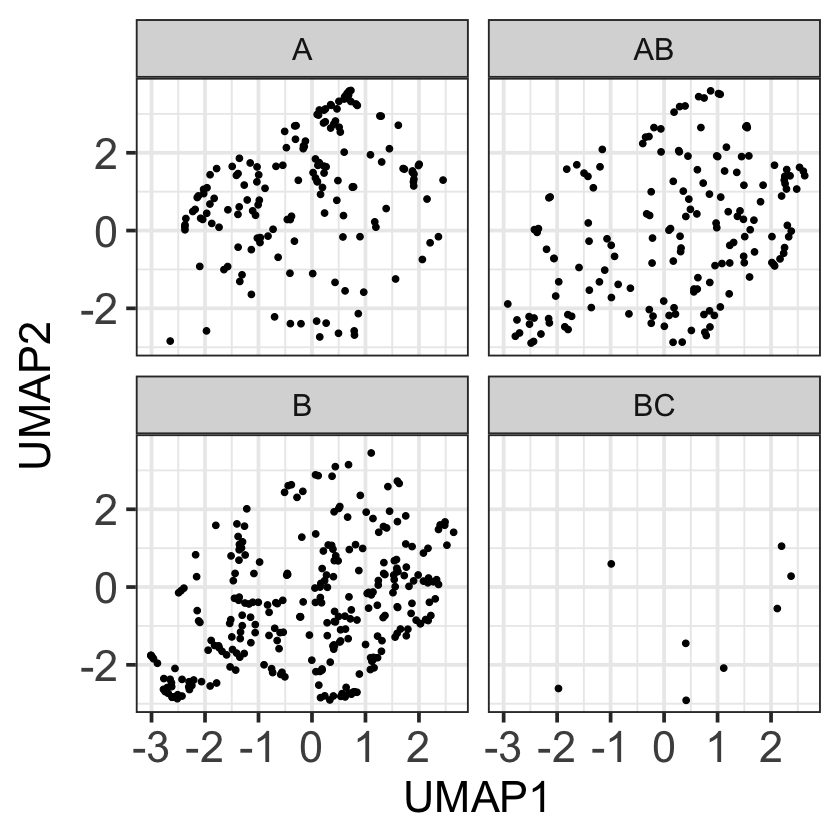

In [117]:
fig.size(7, 7)
#Merge it all together and look at per genotype distribution
CD45_filt %>% inner_join(read_csv("RNA_ADT_Barcodes.csv")) %>% mutate(cell = paste0(RNA_cell, "_",RNA_Barcode)) %>% select(plate_well, cell) %>% unique %>% 
inner_join(CD45_gen) %>% inner_join(meta_umap_adt_CD45.clust) %>% add_count(AllelicGenotype) %>% filter(n>5) %>%


ggplot()+
    geom_point(aes(x= UMAP1, y = UMAP2) )+
  theme_gy() + 
theme(legend.position = "right")+
labs(color = "Genotype") +
facet_wrap(. ~ AllelicGenotype)

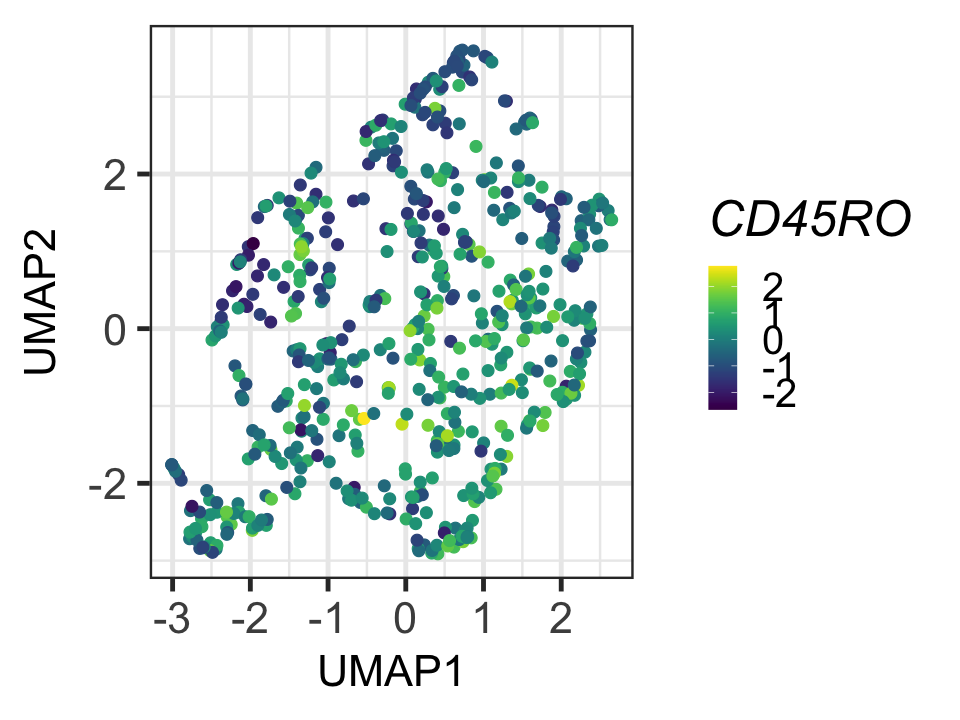

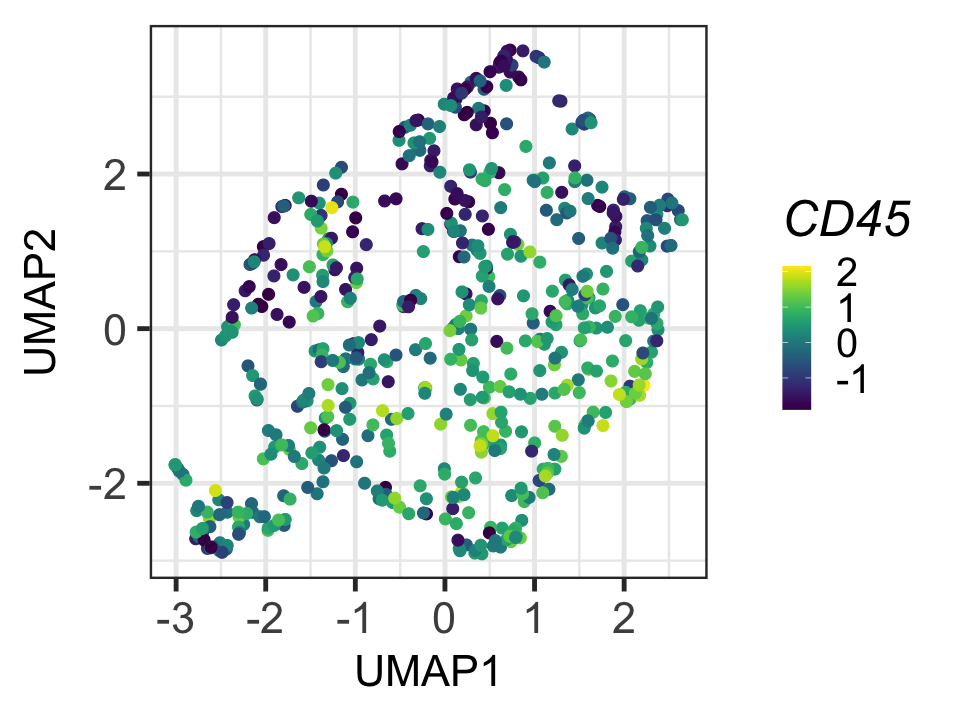

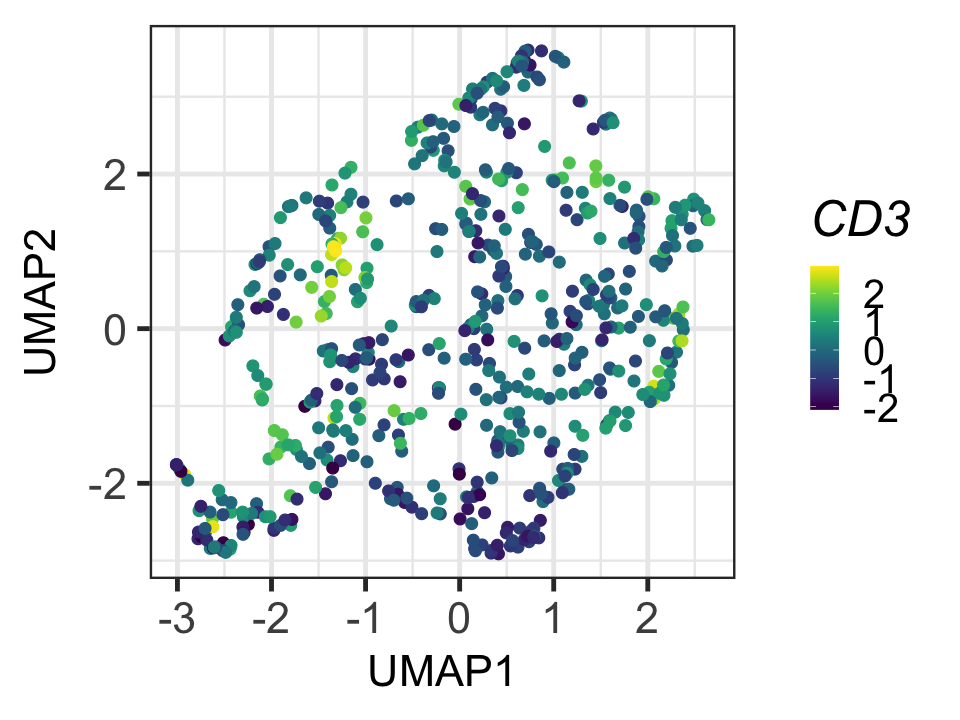

In [106]:
plot_exprs(scale_adt, meta_umap_adt_CD45, c("CD45RO", "CD45", "CD3"))

In [118]:
df<-meta_umap_adt_CD45.clust %>% arrange(cluster)
matrix <- scale_adt[,df$cell]

dge_CD45 = wilcoxauc(matrix, df$cluster)
var_genes_CD45 = top_markers(dge_CD45, 10) %>% head(10) %>% select(-rank) %>% 
                        unlist %>% unique 
cmax = abs(matrix[var_genes_CD45,]) %>% unlist %>% max #%>% quantile(.995)

# Data frame with column annotations.
mat_col <- data.frame(cluster = df$cluster)
rownames(mat_col) <- rownames(df)


# Sort dendogram
mat_cluster_cols <- hclust(dist(t(matrix[var_genes_CD45, ])))
mat_cluster_cols <- sort_hclust(mat_cluster_cols)
mat_cluster_rows <- sort_hclust(hclust(dist(matrix[var_genes_CD45, ])))

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Integrin_β7' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Integrin_β7' in 'mbcsToSbcs': dot substituted for <b2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'FcεRIα' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'FcεRIα' in 'mbcsToSbcs': dot substituted for <b5>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'FcεRIα' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'FcεRIα' in 'mbcsToSbcs': dot substituted for <b1>”
Warning message in grid.Call.graphics(C_text, as

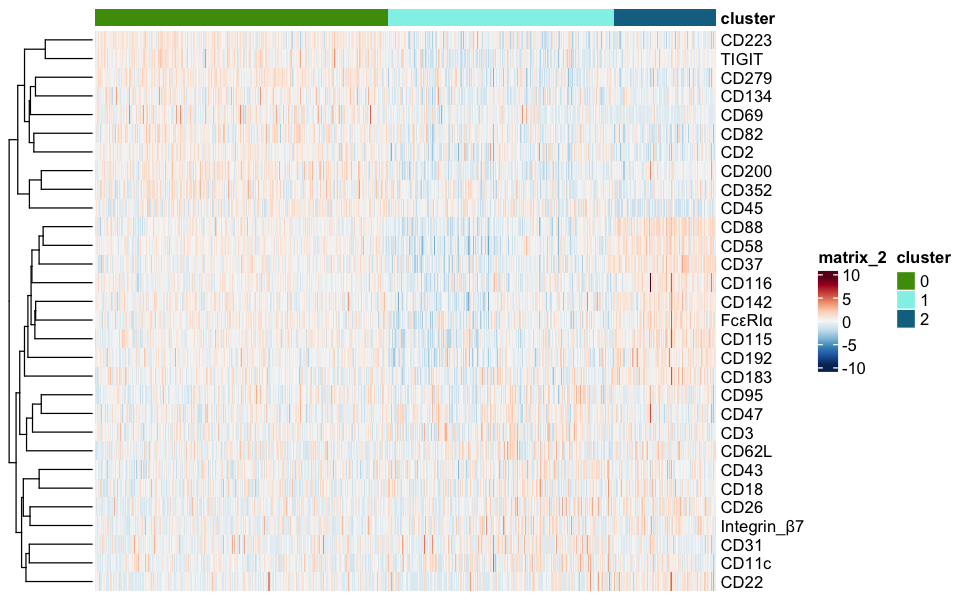

In [119]:
fig.size(5, 8)
pheatmap(as.matrix(matrix[c(var_genes_CD45), df$cell]),
         breaks = seq(-cmax, cmax, length.out = 100),
        color = colorRampPalette(brewer.pal(11, "RdBu"))(100) %>% rev,
        show_colnames = FALSE,
         annotation_col = mat_col, 
         fontsize = 10,
         cluster_cols = F,
         #annotation_colors = list(cluster = c(
         #                         `0` = "#66C2A5", 
          #                        `1` = "#FC8D62" 
                                  #`2` = "#8DA0CB"
           #                          )),
        cluster_rows = mat_cluster_rows,

        )

# Figures

In [120]:
CD45Plots <- read_csv("CD45Plots_Updated.csv")

Rows: 618 Columns: 32
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (16): Barcode_DNA, Well_ID, plate_well, genotype, AllelicGenotype, DNA_c...
dbl (16): PB_CD81, BV605_CD45, BV750_CD45, SSC, FSC, FITC_CD45, PE_CD81, PEC...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Bulk CD45

In [1774]:
read_csv("BulkCD45.csv")

Rows: 24 Columns: 6
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (3): Sample, Experiment, Status
dbl (3): PercentParent, CD4MFI, CD25MFI

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Sample,Experiment,Status,PercentParent,CD4MFI,CD25MFI
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
C0002YB,CRISPR,Het,31.90,4361,2168
C0002YB,Control,Het,3.41,3975,1209
C0004YB,CRISPR,Het,37.70,4066,2755
C0004YB,Control,Het,7.84,3386,1188
C0006YB,CRISPR,Het,28.10,4254,1561
C0006YB,Control,Het,29.90,3808,1579
C0010YB,CRISPR,Het,26.10,4352,1300
C0010YB,Control,Het,2.54,3942,1232
C0002YB,CRISPR,WT,21.00,3641,2198


Rows: 32 Columns: 6
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (3): Sample, Experiment, Status
dbl (3): PercentParent, CD4MFI, CD25MFI

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“Removed 4 rows containing missing values (`stat_boxplot()`).”
Warning message:
“Removed 4 rows containing missing values (`geom_line()`).”
Warning message:
“Removed 4 rows containing missing values (`geom_point()`).”
Rows: 32 Columns: 6
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (3): Sample, Experiment, Status
dbl (3): PercentParent, CD4MFI, CD25MFI

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE

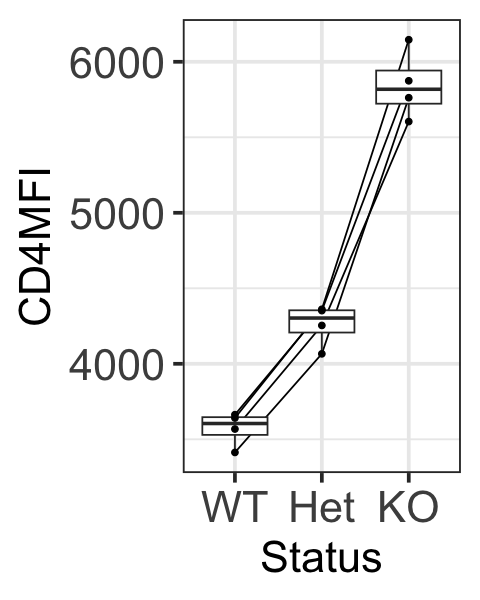

Rows: 32 Columns: 6
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (3): Sample, Experiment, Status
dbl (3): PercentParent, CD4MFI, CD25MFI

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


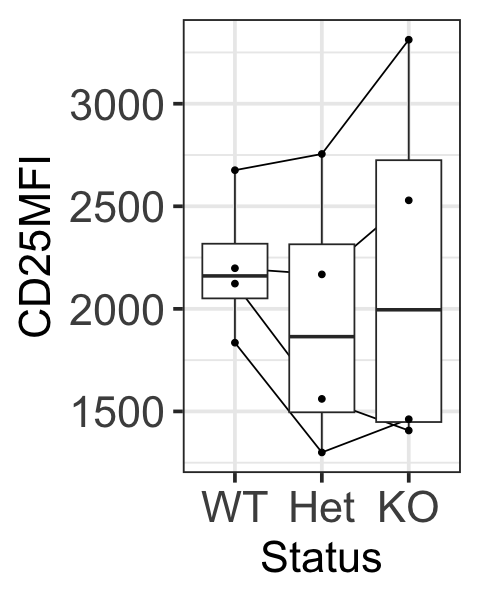

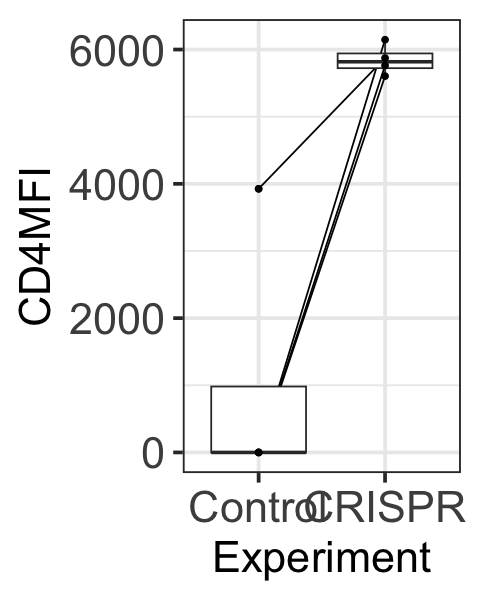

In [81]:
fig.size(5,4)
read_csv("BulkCD45.csv") %>% filter(Experiment == "CRISPR") %>%
ggplot(aes(Status, CD4MFI))  + 
geom_line(aes(group = Sample)) + geom_boxplot() + 
scale_x_discrete(limits = c("WT", "Het", "KO"))+ geom_point() + 
theme_gy() 

fig.size(5,4)
read_csv("BulkCD45.csv") %>% filter(Experiment == "CRISPR") %>%
ggplot(aes(Status, CD25MFI))  + 
geom_line(aes(group = Sample)) + geom_boxplot() + 
scale_x_discrete(limits = c("WT", "Het", "KO"))+ geom_point() + 
theme_gy() 

fig.size(5,4)
read_csv("BulkCD45.csv") %>% filter(Status == "KO") %>%
ggplot(aes(Experiment, CD4MFI))  + 
geom_line(aes(group = Sample)) + geom_boxplot() + geom_point() + 
theme_gy() 



In [ ]:
fig.size(5,4)
read_csv("BulkCD45.csv") %>% filter(Experiment == "CRISPR") %>%
ggplot(aes(Status, CD25MFI))  + 
geom_line(aes(group = Sample)) + geom_boxplot() + 
scale_x_discrete(limits = c("WT", "Het", "KO"))+ geom_point() + 
theme_gy() 

In [75]:
compare_means(CD25MFI~Experiment, BulkCD45)

.y.,group1,group2,p,p.adj,p.format,p.signif,method
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
CD25MFI,CRISPR,Control,0.01666011,0.017,0.017,*,Wilcoxon


## DNA

In [121]:
#Defineplotting Order
order <- CD45Plots$genotype %>% table %>% as_data_frame %>% arrange(`n`)
order <- as.character(order$`.`)

In [122]:
g <- CD45Plots %>% filter(genotype_count > 5) %>% dplyr::select(Barcode_DNA, Well_ID) %>% inner_join(CD45_filt) %>% Plotting_Alleles

Joining with `by = join_by(Barcode_DNA, Well_ID)`


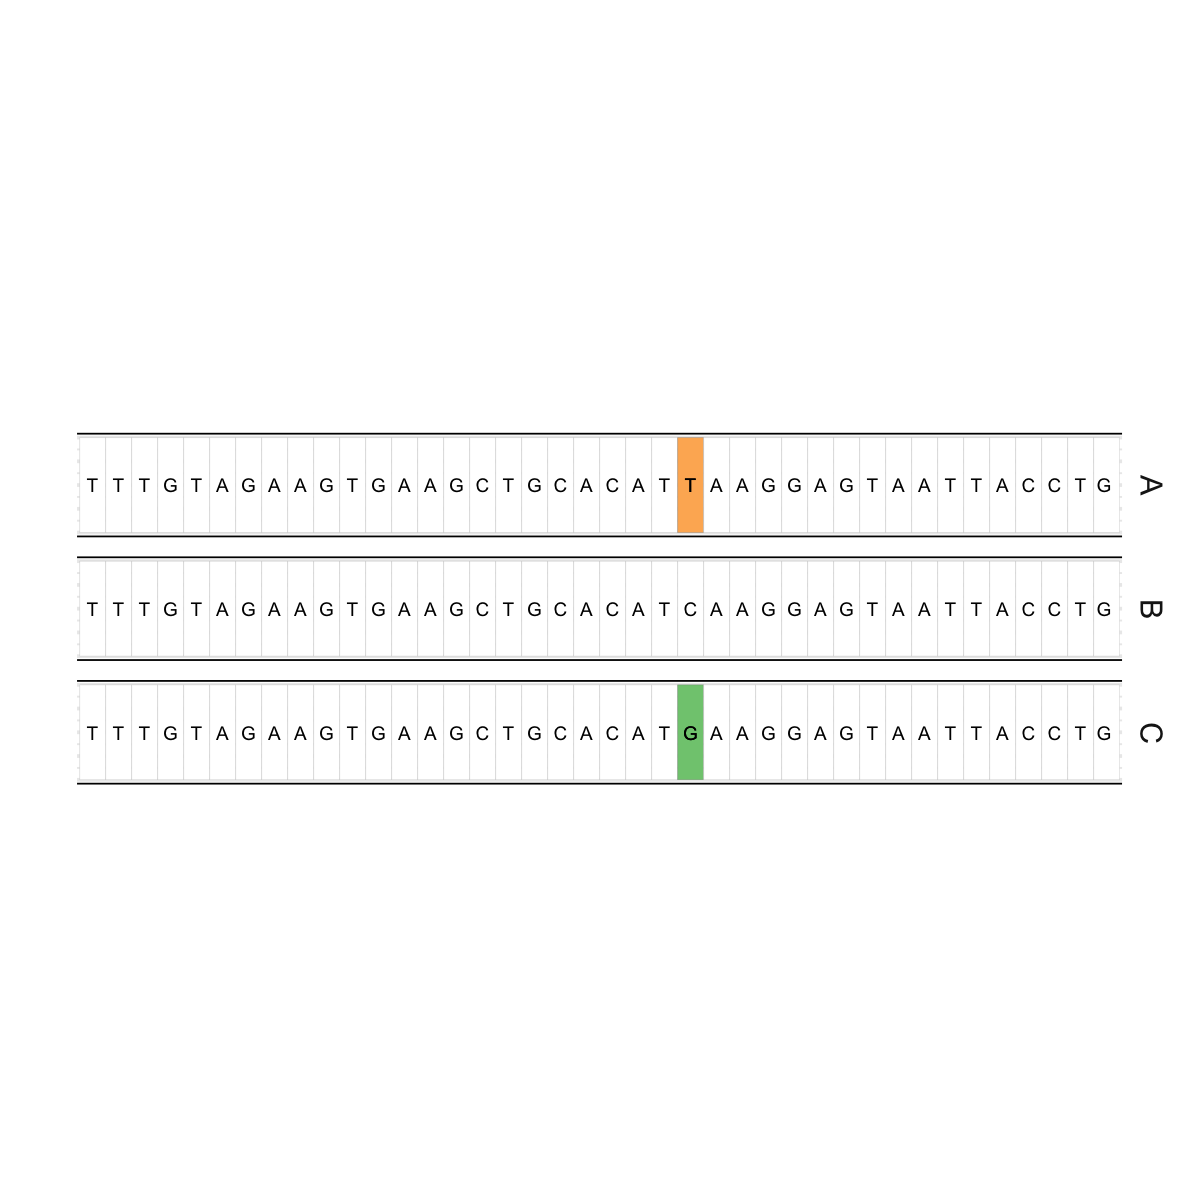

In [123]:
g

In [124]:
#Reorder!
g$data$genotypes <- factor(g$data$genotypes, levels = rev(c("B","A", "C", "D")))

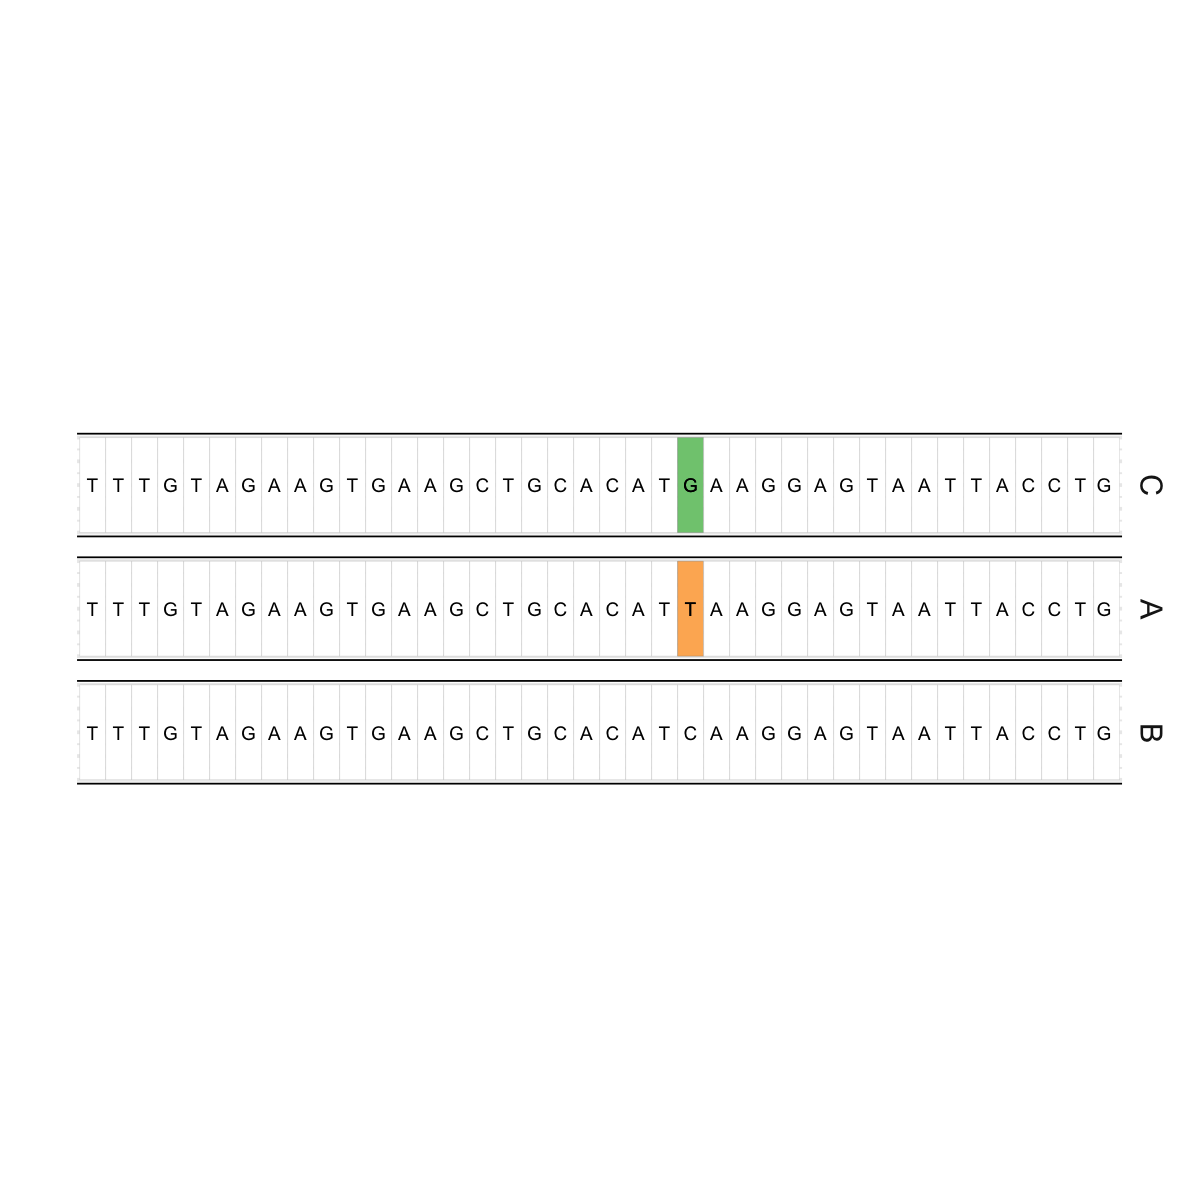

In [125]:
g

In [802]:
g %>% ggsave(filename = "CD45_Alleles.png")

Saving 7 x 7 in image
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“Unable to calculate text width/height (using zero)”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“Unable to calculate text width/height (using zero)”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“Unable to calculate text width/height (using zero)”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“Unable to calculate text width/height (using zero)”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“Unable to calculate text width/height (using zero)”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“Unable to calculate text width/height (using zero)”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“Unable to calculate text width/height (using zero)”
Warning message in grid.Call(C_te

`summarise()` has grouped output by 'as.factor(Edited_Index)', 'as.factor(Individual_Index)'. You can override using the `.groups` argument.
Joining with `by = join_by(genotype, Individual_Index, Edited_Index)`


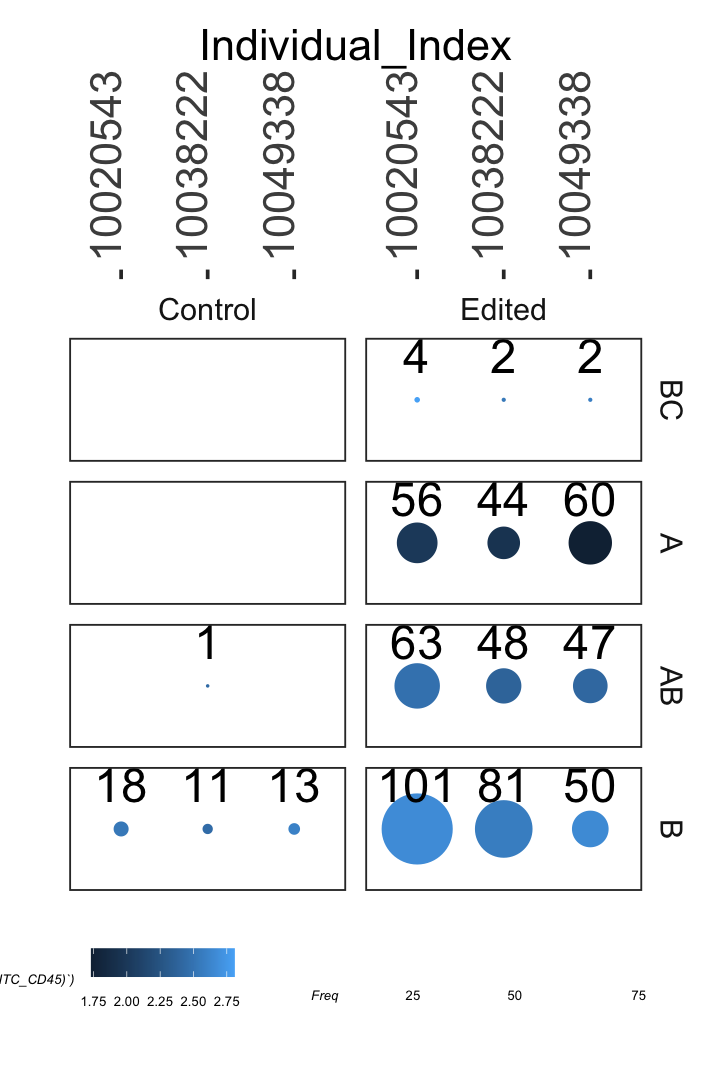

In [126]:
#Plotting number of cell per genotype and condition. 

test2 <- filter(CD45Plots, genotype_count >5) # Filter for > 5 cells per genotype

fig.size(9,6)
g <- 

table(test2$AllelicGenotype, test2$Individual_Index, test2$Edited_Index) %>% 
as.data.frame() %>% rename(Individual_Index = Var2, Edited_Index = Var3, genotype = Var1) %>% 
inner_join( 
test2 %>% group_by(as.factor(Edited_Index), as.factor(Individual_Index), as.factor(AllelicGenotype)) %>% 
    summarise(mean(FITC_CD45)) %>% rename(Individual_Index = `as.factor(Individual_Index)`, 
                                          Edited_Index = `as.factor(Edited_Index)`, genotype = `as.factor(AllelicGenotype)`)
)%>% na.omit%>% {
    
    ggplot(., aes(Individual_Index, 
                  fill = log10(`mean(FITC_CD45)`), size = Freq)) +
      geom_point(aes(y = 0),shape = 21, stroke = 0) +
      #geom_hline(yintercept = seq(.5, 4.5, 1), size = .2) +
  scale_x_discrete(position = "top") +
  scale_radius(range = c(1,20)) +
    geom_text(aes(y = 0, label = Freq), size =10, vjust = -0.8)+
  theme_gy() +
  theme(legend.position = "bottom", 
        panel.grid.major = element_blank(),
        legend.text = element_text(size = 8),
        legend.title = element_text(size = 8), 
       axis.text.x = element_text(angle = 90)) + 
    ylab("") + 
    scale_y_discrete(expand = c(0.1,0.5)) + 
    facet_grid(factor((genotype), levels = rev(c("B", "AB", "A", "BC")))~Edited_Index) + 
    theme(
  strip.background = element_blank(),
  #strip.text.x = element_blank(), 
    #panel.border=element_blank(), 
   # strip.text.y = element_blank()  
        )
} 
plot(g)
suppressWarnings({ 
    ggsave(g, filename = "g.png", device = "png", dpi = 300, width = 6, height = 9)
  })

In [127]:
## Plotting normalization
norm_adt <- singlecellmethods::normalizeData(counts_adt_filt, method = "cellCLR")
norm_exprs <- singlecellmethods::normalizeData(filt_exprs, method = "log")

Joining with `by = join_by(cell)`


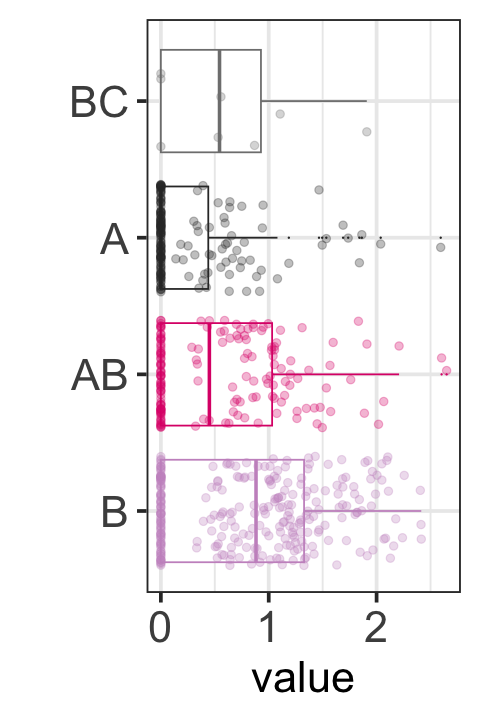

In [128]:
g <- 

norm_exprs["PTPRC",] %>% as_tibble(rownames = "cell") %>% inner_join(CD45Plots) %>%  
    filter(genotype_count >5) %>% na.omit() %>%

ggplot(aes(x = factor(AllelicGenotype, levels = (c("B", "AB", "A", "BC"))), 
           y = value, 
           color = factor(AllelicGenotype, levels = (c("B", "AB", "A", "BC"))))) + 
    geom_boxplot(outlier.size = 0) +
     geom_jitter(alpha = 0.3, size = 2) +   
    theme_gy() + 
theme(legend.position = "none")+ 
xlab("") + 
scale_color_manual(values =c( 
              "BC" = "grey50",
                  "7" = "grey50",
                  "BC" = "grey50",
                  "B" = "#C994C7",
                  "AB" = "#DD1C77", 
                  "A" = "grey20"))+ 

coord_flip()
fig.size(6,4)
plot(g)
## save plot
suppressWarnings({ 
    ggsave(g, filename = "g2.png", device = "png", dpi = 300, width = 4, height = 6)
    })


# RNA linear modeling

In [ ]:
### Excluding plate 1,  unreliable DNA data.

In [131]:
## Subsetting my Condition and fixing genotype. Removing BC genotype. (too few cells)
CD45Plots2 <- filter(CD45Plots, AllelicGenotype %in% c("A","AB","B")) %>% mutate(Dosage = ifelse(
AllelicGenotype == "B", 0, ifelse(AllelicGenotype == "A", 2, 1))) %>% filter(Edited_Index == "Edited") %>% na.omit 

In [132]:
CD45Plots3 <- filter(CD45Plots, AllelicGenotype %in% c("A","AB","B")) %>% mutate(Dosage = ifelse(
AllelicGenotype == "B", 0, ifelse(AllelicGenotype == "A", 2, 1))) %>% na.omit


## Linear Modeling

In [591]:
# Linear modeling. Negative binomial to Dosage. CRISPR condition only.
df <- CD45Plots2
cells <- df$cell
df$Individual_Index <- as.factor(df$Individual_Index)
df$Dosage %>% table
Exprs <- exprs[, df$cell] #expression in this set of cells

nCells = rowSums(Exprs > 0)
gene_qc = data.frame(nCells = nCells %>% sort %>% rev, rank = seq(1, length(nCells)))

Exprs <- filt_exprs[gene_qc %>% filter(nCells > length(cells)*0.15) %>% rownames, cells] #Expressed in 30% of cells. 
genes <- rownames(Exprs)

Exprs %>% dim
genes %>% length

suppressMessages({
    suppressWarnings({
CD45_lm_Dosage <- 
    sapply(genes, function(i){ 
        

    lm0<- glm.nb(data = df,  
          formula = (Exprs)[i,] ~ 1 + log10(nUMI.y) + Plate + Individual_Index, 
            )
    
    lm1 <- glm.nb(data = df,  
          formula = (Exprs)[i,] ~ 1  + log10(nUMI.y) + Plate + Individual_Index + Dosage, 
               )
    
     return(c(coefficients(lm1), "pval" = anova(lm0,lm1, test = "Chisq")[2,8]))
        })
    })
    })

CD45_lm_Dosage<- 
    t(CD45_lm_Dosage) %>% 
    as_tibble(rownames = "gene") %>% 
    mutate(padjBH = p.adjust(pval, method = "BH"))

.
  0   1   2 
232 158 160 

[1] 5511  550

[1] 5511

In [593]:
CD45_lm_Dosage %>% filter(padjBH < 0.05)

gene,(Intercept),log10(nUMI.y),PlateP3,PlateP4,Individual_Index10038222,Individual_Index10049338,Dosage,pval,padjBH
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TNFRSF4,-4.197007,1.976669,0.05295609,0.14373288,-0.1779541,0.098516208,-0.2730704,2.585736e-06,3.562498e-03
TRBC2,-6.128260,2.293284,0.20030552,0.10967598,-0.4028057,-0.068585180,-0.2459947,2.601048e-05,2.866875e-02
CHCHD10,-10.604930,2.744217,-0.15127065,0.07536001,-0.2717936,-0.001834315,0.3580782,2.263081e-06,3.562498e-03
PTPRC,-9.118225,2.445656,0.28734860,0.19386950,-0.2241544,-0.256680657,-0.6525851,5.551115e-16,3.059220e-12
ANXA3,-13.432073,2.556328,0.28211425,0.02790393,0.9040109,0.343280105,0.8785004,2.275742e-08,6.270806e-05


In [594]:
CD45_lm_Dosage%>% write_csv("CD45_lm_Dosage.csv") # export

In [595]:
CD45_lm_Dosage %>% filter(padjBH < 0.05) %>% arrange(pval) # PTPRC is the top hit. Makes sense.

gene,(Intercept),log10(nUMI.y),PlateP3,PlateP4,Individual_Index10038222,Individual_Index10049338,Dosage,pval,padjBH
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PTPRC,-9.118225,2.445656,0.28734860,0.19386950,-0.2241544,-0.256680657,-0.6525851,5.551115e-16,3.059220e-12
ANXA3,-13.432073,2.556328,0.28211425,0.02790393,0.9040109,0.343280105,0.8785004,2.275742e-08,6.270806e-05
CHCHD10,-10.604930,2.744217,-0.15127065,0.07536001,-0.2717936,-0.001834315,0.3580782,2.263081e-06,3.562498e-03
TNFRSF4,-4.197007,1.976669,0.05295609,0.14373288,-0.1779541,0.098516208,-0.2730704,2.585736e-06,3.562498e-03
TRBC2,-6.128260,2.293284,0.20030552,0.10967598,-0.4028057,-0.068585180,-0.2459947,2.601048e-05,2.866875e-02


In [596]:
# Linear model to Condition. 
df <- CD45Plots3
cells <- df$cell
df$Individual_Index <- as.factor(df$Individual_Index)
df$Dosage %>% table
Exprs <- exprs[, df$cell] #expression in this set of cells

nCells = rowSums(Exprs > 0)
gene_qc = data.frame(nCells = nCells %>% sort %>% rev, rank = seq(1, length(nCells)))

Exprs <- filt_exprs[gene_qc %>% filter(nCells > length(cells)*0.15) %>% rownames, cells] #Expressed in 15% of cells. 
genes <- rownames(Exprs)
Exprs %>% dim

suppressMessages({
    suppressWarnings({
CD45_lm_Bulk <- 
    sapply(genes, function(i){ 
        

    lm0<- glm.nb(data = df,  
          formula = (Exprs)[i,] ~ 1 + log10(nUMI.y) + Plate + Individual_Index, 
            )
    
    lm1 <- glm.nb(data = df,  
          formula = (Exprs)[i,] ~ 1  + log10(nUMI.y) + Plate + Individual_Index + Edited_Index, 
               )
    
     return(c(coefficients(lm1), "pval" = anova(lm0,lm1, test = "Chisq")[2,8]))
        })
    })
    })

CD45_lm_Bulk<- 
    t(CD45_lm_Bulk) %>% 
    as_tibble(rownames = "gene") %>% 
    mutate(padjBH = p.adjust(pval, method = "BH"))

.
  0   1   2 
274 159 160 

[1] 5583  593

In [597]:
CD45_lm_Bulk %>% write_csv("CD45_lm_Bulk.csv")

## ADT modeling

In [606]:
# Linear model of ADT to Dosage. negative binomial. 

df <- CD45Plots2
df$Individual_Index <- as.factor(df$Individual_Index)
df$Dosage %>% table
Exprs <- counts_ADT_filt[, df$cell]
gene <- intersect(genes, rownames(Exprs))#defined above on variance to mean ratio
gene <- genes[-grep(genes, pattern = "^Ig")] #Remove Ig genes

Exprs %>% dim

suppressMessages({
    suppressWarnings({
CD45_lm_Dosage_adt <- 
    sapply(gene, function(i){ 
        

    lm0<- glm.nb(data = df,  
          formula = (Exprs)[i,] ~ 1 + log10(nUMI.x) + Plate + Individual_Index, 
            )
    
    lm1 <- glm.nb(data = df,  
          formula = (Exprs)[i,] ~ 1  + log10(nUMI.x) + Plate + Individual_Index + Dosage, 
               )
     return(c(coefficients(lm1), "pval" = anova(lm0,lm1, test = "Chisq")[2,8]))
        })
    })
    })

CD45_lm_Dosage_adt<- 
    t(CD45_lm_Dosage_adt) %>% 
    as_tibble(rownames = "gene") %>% 
    mutate(padjBH = p.adjust(pval, method = "BH"))

.
  0   1   2 
232 158 160 

[1] 154 550

In [608]:
CD45_lm_Dosage_adt %>% write_csv("CD45_lm_Dosage_adt.csv")

In [607]:
CD45_lm_Dosage_adt %>% arrange(padjBH,Dosage) %>% filter(padjBH < 0.05) # Lotta hits. CD45 is the top. 

gene,(Intercept),log10(nUMI.x),PlateP3,PlateP4,Individual_Index10038222,Individual_Index10049338,Dosage,pval,padjBH
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CD45,-1.8723572,1.4266674,0.44372596,0.61880528,-0.066425401,-0.273852387,-0.80469451,0.000000e+00,0.000000e+00
CD45RO,-1.7274590,1.8477939,0.16104698,0.16260710,-0.150790637,-0.148539053,-0.66459389,0.000000e+00,0.000000e+00
CD45RA,-2.8131215,1.3465740,0.26195248,0.29808833,0.073343324,-0.020494107,-0.49233375,0.000000e+00,0.000000e+00
CD4,-4.1362242,2.0724890,0.09305513,0.05493361,0.131211265,-0.191142812,0.29093164,0.000000e+00,0.000000e+00
CD37,-7.7258942,2.6543479,-0.10372331,-0.01891489,-0.058577403,-0.102967189,0.12633770,3.089372e-09,9.020967e-08
CD134,-3.5624129,2.2200321,0.07251314,0.02256254,-0.105662575,0.154150104,-0.13478855,4.764480e-07,1.159357e-05
CD88,-6.7192251,2.6233476,-0.07790305,-0.04928804,-0.108881067,-0.074695589,0.08894944,6.300501e-07,1.314105e-05
CD56,-4.2296093,1.3725877,0.65719579,0.73200143,0.524453689,0.030722662,-0.31885811,1.573602e-06,2.871824e-05
CD8,-9.3655728,2.6628598,-0.02773827,-0.39406213,-0.041237426,0.142493415,-0.36100527,3.957550e-06,5.252749e-05


Joining with `by = join_by(cell)`
Joining with `by = join_by(cell)`


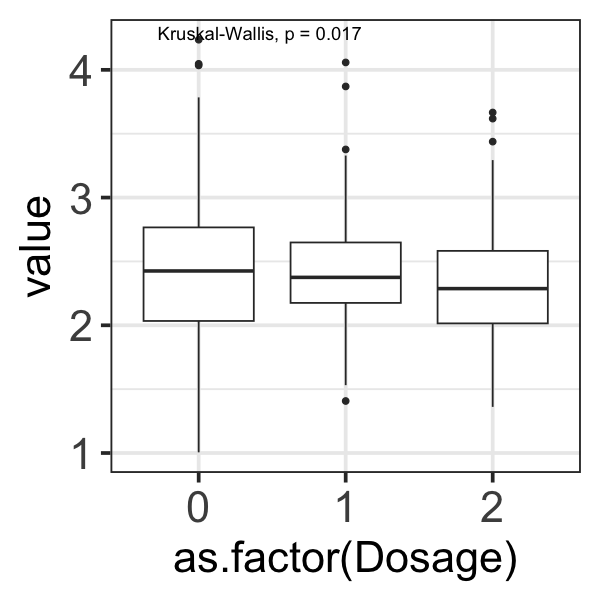

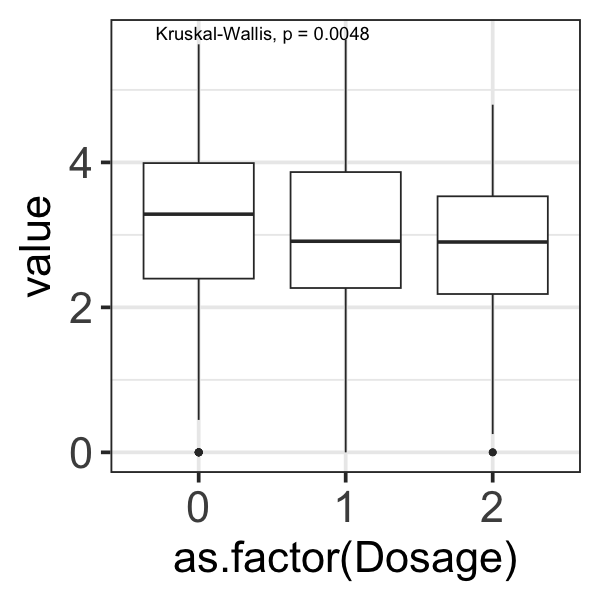

In [133]:
fig.size(5,5) ## Magnificent corelation of protein and genotype!!! 
norm_adt["CD134",] %>% as_tibble(rownames = "cell") %>% inner_join(CD45Plots2) %>% 
ggplot(aes(as.factor(Dosage), value)) + geom_boxplot() + theme_gy() + stat_compare_means()

norm_exprs["TNFRSF4",] %>% as_tibble(rownames = "cell") %>% inner_join(CD45Plots2) %>% 
ggplot(aes(as.factor(Dosage), value)) + geom_boxplot() + theme_gy()+ stat_compare_means()

In [610]:
# Linear model to Condition

df <- CD45Plots3
df$Individual_Index <- as.factor(df$Individual_Index)
df$Dosage %>% table
Exprs <- counts_ADT_filt[, df$cell]
gene <- intersect(genes, rownames(Exprs))#defined above on variance to mean ratio
gene <- genes[-grep(genes, pattern = "^Ig")] #Remove Ig genes

Exprs %>% dim

suppressMessages({
    suppressWarnings({
CD45_lm_Edited_adt <- 
    sapply(genes, function(i){ 
        

    lm0<- glm.nb(data = df,  
          formula = (Exprs)[i,] ~ 1 + log10(nUMI.x) + Plate + Individual_Index, 
            )
    
    lm1 <- glm.nb(data = df,  
          formula = (Exprs)[i,] ~ 1  + log10(nUMI.x) + Plate + Individual_Index + Edited_Index, 
               )
     return(c(coefficients(lm1), "pval" = anova(lm0,lm1, test = "Chisq")[2,8]))
        })
    })
    })

CD45_lm_Edited_adt<- 
    t(CD45_lm_Edited_adt) %>% 
    as_tibble(rownames = "gene") %>% 
    mutate(padjBH = p.adjust(pval, method = "BH"))

.
  0   1   2 
274 159 160 

[1] 154 593

In [71]:
CD45_lm_Edited_adt %>% write_csv("CD45_lm_Edited_adt.csv")

In [612]:
CD45_lm_Edited_adt %>% arrange(padjBH)

gene,(Intercept),log10(nUMI.x),PlateP3,PlateP4,Individual_Index10038222,Individual_Index10049338,Edited_IndexEdited,pval,padjBH
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CD25,-3.8542193,1.9670867,0.176997507,0.183007936,0.213755993,0.0002996029,0.4439374,6.018220e-06,0.000902733
CD62L,-2.4697693,1.8737337,0.410409345,0.088194572,0.028442684,0.0059111887,-0.7457362,2.237789e-05,0.001678342
CD279,-1.9522250,2.1033016,0.077520005,0.054592003,0.212383179,0.2155719640,0.3683354,9.225021e-05,0.002767506
CD7,-5.2269021,2.0469128,0.185514696,0.320033022,-0.244274217,0.0612923475,0.4411289,7.571943e-05,0.002767506
CD28,-6.5876095,2.2945611,-0.194630749,-0.152152196,-0.131410964,-0.1735866472,-0.4342107,5.765688e-05,0.002767506
GPR56,-6.1439764,2.1043726,-0.268649049,-0.130509886,-0.195547697,0.0252973162,0.5628815,1.455142e-04,0.003637856
CD4,-4.6826928,2.2124090,0.058002127,0.047110057,0.142410307,-0.1132593961,0.3001220,3.334588e-04,0.007145545
CD72,-4.7728105,1.5861629,0.331212773,0.308548185,0.940367865,0.2423894795,0.7277308,4.625889e-04,0.008673542
CD55,-3.1126513,1.9574564,-0.031108909,-0.037156317,0.004117432,-0.1545291341,0.2740340,2.339765e-03,0.038996091


## Differential Gene and Protein Combination.

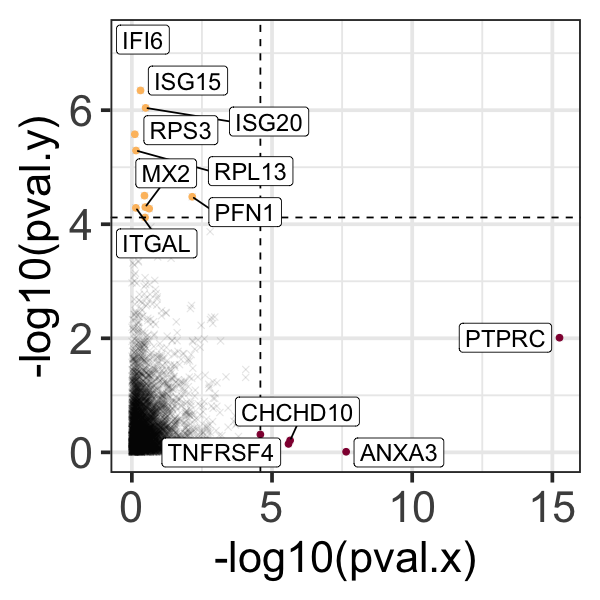

In [620]:
fig.size(5,5)
inner_join(CD45_lm_Dosage  %>% mutate(Condition = "Dosage"),
CD45_lm_Bulk %>% mutate(Condition = "Edited"), by = "gene") %>% 

{
ggplot(data = ., aes(-log10(pval.x), -log10(pval.y))) + 
    geom_point(alpha = 0.1, shape = 4)+
    geom_point(data = filter(`.`, padjBH.x < 0.05), color = "#91003F") +
     geom_point(data = filter(`.`, padjBH.y < 0.05), color = "#FDBF6E") +
    theme_gy() + 
    geom_vline(xintercept = -log10( 
    CD45_lm_Dosage %>% filter(padjBH < 0.05) %>% arrange(-pval) %>% head(1) %>% with(pval)
    ), linetype = 2) + 
    geom_hline(yintercept =  -log10( 
    CD45_lm_Bulk %>% filter(padjBH < 0.05) %>% arrange(-pval) %>% head(1) %>% with(pval)
    ), linetype = 2) + 
    geom_label_repel(data = filter(`.`, padjBH.x < 0.01), aes(label = gene), size  =5) +
     geom_label_repel(data = filter(`.`, padjBH.y < 0.05), aes(label = gene), size  =5)
    
    }

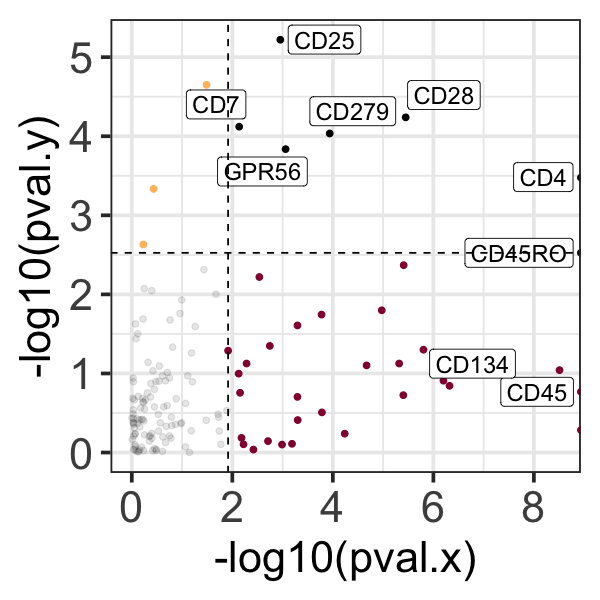

In [621]:
fig.size(5,5)
inner_join(CD45_lm_Dosage_adt  %>% mutate(Condition = "Dosage"),
CD45_lm_Edited_adt %>% mutate(Condition = "Edited"), by = "gene") %>% 

{
ggplot(data = ., aes(-log10(pval.x), -log10(pval.y)))  +
    geom_point(alpha = 0.1)+
    geom_point(data = filter(`.`, padjBH.x < 0.05 & padjBH.y > 0.05), color = "#91003F") +
     geom_point(data = filter(`.`, padjBH.y < 0.05 & padjBH.x > 0.05), color = "#FDBF6E") +
    geom_point(data = filter(`.`, padjBH.y < 0.05 & padjBH.x < 0.05), color = "black")+
    theme_gy()+
     #geom_label_repel(data = filter(`.`, padjBH.x < 0.05 & padjBH.y > 0.05), aes(label = Gene)) +
     #geom_label_repel(data = filter(`.`, padjBH.y < 0.05 & padjBH.x > 0.05), aes(label = Gene)) + 
     geom_label_repel(data = filter(`.`, padjBH.y < 0.05 & padjBH.x < 0.05), aes(label = gene), size  =5) +
    geom_vline(xintercept = -log10( 
    CD45_lm_Dosage_adt %>% filter(padjBH < 0.05) %>% arrange(-pval) %>% head(1) %>% with(pval)
    ), linetype = 2) + 
    geom_hline(yintercept =  -log10( 
    CD45_lm_Edited_adt %>% filter(padjBH < 0.05) %>% arrange(-pval) %>% head(1) %>% with(pval)
    ), linetype = 2) + 
    geom_label_repel(data = filter(`.`,gene == "CD45"), aes(label = gene), size  =5)+ 
    geom_label_repel(data = filter(`.`,gene == "CD134"), aes(label = gene), size  =5)
    
    }

In [623]:
#Function for creating heatmap plots of significant genes from scaled exprs 
##Define gene set. 
sig_genes_Dosage <- CD45_lm_Dosage %>% filter(padjBH < 0.05) %>% top_n(5, wt=-pval) %>% with(gene) # select top 5
sig_genes_Edited<- CD45_lm_Bulk %>% filter(padjBH < 0.05) %>% top_n(5, wt=-pval) %>%  with(gene) # select top 5
sig_genes <- union(sig_genes_Dosage,sig_genes_Edited)
#Scale data
scale_exprs <- exprs %>% normalizeData(method = "log") %>% scaleData()

#Pull out data and pivot longer. 
df<- CD45Plots3 %>% filter(Edited_Index == "Edited") %>% 
    mutate(group = paste0(Dosage,"_", Individual_Index)) %>% 
    dplyr::select(cell, group) %>% 
    inner_join(t(scale_exprs[sig_genes, CD45Plots3$cell]) %>%
                   as_tibble(rownames = "cell")) %>% 
    group_by(group) %>% 
    summarise_all(.funs = mean) %>% 
    dplyr::select(-cell) %>% 
    pivot_longer(-group) 

df2 <- CD45Plots3 %>%
    mutate(group = paste0(Edited_Index,"_", Individual_Index)) %>%
    dplyr::select(cell, group) %>% 
    inner_join(t(scale_exprs[sig_genes, CD45Plots3$cell]) %>%
                   as_tibble(rownames = "cell")) %>% 
    group_by(group) %>% 
    summarise_all(.funs = mean) %>% 
    dplyr::select(-cell) %>% 
    pivot_longer(-group) 

#rename dfs
colnames(df) <- c("X", "gene", "value")
colnames(df2) <- c("X", "gene", "value")

#Order geneset
test <- scale_exprs[sig_genes_Dosage, CD45Plots3$cell] %>% dist %>% hclust
test2 <- scale_exprs[sig_genes_Edited, CD45Plots3$cell] %>% dist %>% hclust
order <- union(sig_genes_Dosage[test$order], sig_genes_Edited[test2$order])

Joining with `by = join_by(cell)`
Warning message:
“There were 9 warnings in `summarise()`.
The first warning was:
ℹ In argument: `cell = (new("standardGeneric", .Data = function (x, ...) ...`.
ℹ In group 1: `group = "0_10020543"`.
Caused by warning in `mean.default()`:
! argument is not numeric or logical: returning NA
ℹ Run `dplyr::last_dplyr_warnings()` to see the 8 remaining warnings.”
Joining with `by = join_by(cell)`
Warning message:
“There were 6 warnings in `summarise()`.
The first warning was:
ℹ In argument: `cell = (new("standardGeneric", .Data = function (x, ...) ...`.
ℹ In group 1: `group = "Control_10020543"`.
Caused by warning in `mean.default()`:
! argument is not numeric or logical: returning NA
ℹ Run `dplyr::last_dplyr_warnings()` to see the 5 remaining warnings.”


Saving 7 x 7 in image


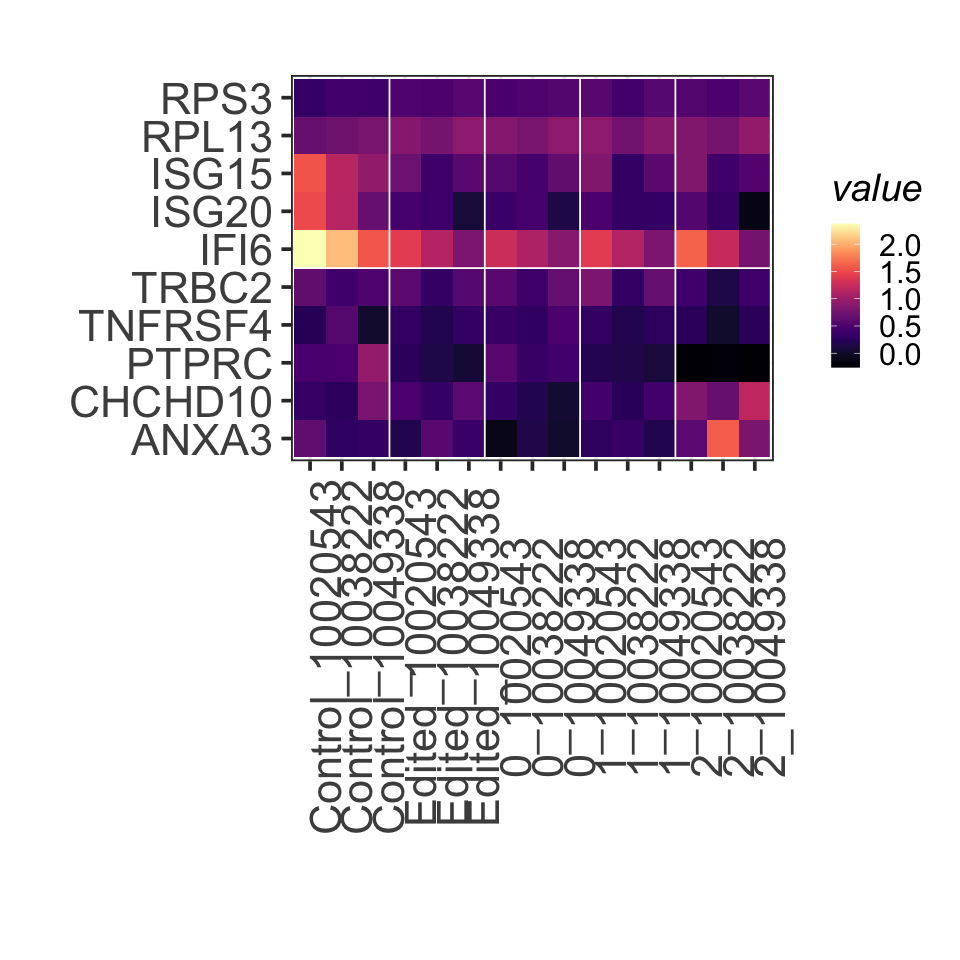

In [624]:
#Plot Figure
fig.size(8,8)
g<-  ggplot() + 
geom_tile(data = df,
          aes(x = X, y = gene, fill = value)) + 
geom_tile(data = df2,
          aes(x = X, y = gene, fill = value)) + 
scale_fill_viridis(option = "magma") + 
theme_gy() + 
scale_y_discrete(limits = c(order)) + 
theme(axis.text.x = element_text(angle = 90)) + 
scale_x_discrete(limits = c(unique(df2$X),unique(df$X))) + 
theme(legend.position = "right") + 
geom_vline(xintercept = c(3.5, 6.5, 9.5,12.5,15.5), color = "white")+
geom_hline(yintercept = sum(sig_genes %in% sig_genes_Dosage)+0.5, color = "white") + 
xlab("") + ylab("")+ 
theme(aspect.ratio = 0.8)

plot(g)
## save the plot
suppressWarnings({ 
    ggsave(g, filename = "g.png", device = "png", dpi = 300)
    })

In [ ]:
## Exact same analysis, but with adt

In [625]:
#Extract ADTs
sig_genes_Dosage_adt <- CD45_lm_Dosage_adt %>% filter(padjBH < 0.05) %>% top_n(wt = -pval, n = 5) %>% with(gene)
sig_genes_Edited_adt<- CD45_lm_Edited_adt %>% filter(padjBH < 0.05) %>% top_n(wt = -pval,n = 5) %>% with(gene)

## gotta manually filter some ADTs that don't make sense. 
sig_genes_Dosage_adt<-
sig_genes_Dosage_adt[!grepl(sig_genes_Dosage_adt, pattern = "Ig")]
sig_genes_Edited_adt <- sig_genes_Edited_adt[!grepl(sig_genes_Edited_adt, pattern = "Ig")]
sig_genes_adt <- union(sig_genes_Dosage_adt,sig_genes_Edited_adt)

#Assign Ordering 
test <- scale_adt[sig_genes_Dosage_adt, CD45Plots3$cell] %>% dist %>% hclust
test2 <- scale_adt[sig_genes_Edited_adt, CD45Plots3$cell] %>% dist %>% hclust
order_adt <- union(sig_genes_Dosage_adt[test$order], sig_genes_Edited_adt[test2$order])

#Define data sets
df_adt<- CD45Plots3 %>% filter(Edited_Index == "Edited") %>% 
    mutate(group = paste0(Dosage,"_", Individual_Index)) %>% 
    dplyr::select(cell, group) %>% 
    inner_join(t(scale_adt[sig_genes_adt, CD45Plots3$cell]) %>%
                   as_tibble(rownames = "cell")) %>% 
    group_by(group) %>% 
    summarise_all(.funs = mean) %>% 
    dplyr::select(-cell) %>% 
    pivot_longer(-group) 

df2_adt <- CD45Plots3 %>%
    mutate(group = paste0(Edited_Index,"_", Individual_Index)) %>%
    dplyr::select(cell, group) %>% 
    inner_join(t(scale_adt[sig_genes_adt, CD45Plots3$cell]) %>%
                   as_tibble(rownames = "cell")) %>% 
    group_by(group) %>% 
    summarise_all(.funs = mean) %>% 
    dplyr::select(-cell) %>% 
    pivot_longer(-group) 

colnames(df_adt) <- c("X", "gene", "value")
colnames(df2_adt) <- c("X", "gene", "value")

Joining with `by = join_by(cell)`
Warning message:
“There were 9 warnings in `summarise()`.
The first warning was:
ℹ In argument: `cell = (new("standardGeneric", .Data = function (x, ...) ...`.
ℹ In group 1: `group = "0_10020543"`.
Caused by warning in `mean.default()`:
! argument is not numeric or logical: returning NA
ℹ Run `dplyr::last_dplyr_warnings()` to see the 8 remaining warnings.”
Joining with `by = join_by(cell)`
Warning message:
“There were 6 warnings in `summarise()`.
The first warning was:
ℹ In argument: `cell = (new("standardGeneric", .Data = function (x, ...) ...`.
ℹ In group 1: `group = "Control_10020543"`.
Caused by warning in `mean.default()`:
! argument is not numeric or logical: returning NA
ℹ Run `dplyr::last_dplyr_warnings()` to see the 5 remaining warnings.”


In [633]:
#adjust order of ADT because of shared. 
order_adt <- c('CD37','CD45RA','CD45','CD45RO','CD4','CD279','CD7','CD25', "CD62L", "CD28")

Saving 7 x 7 in image


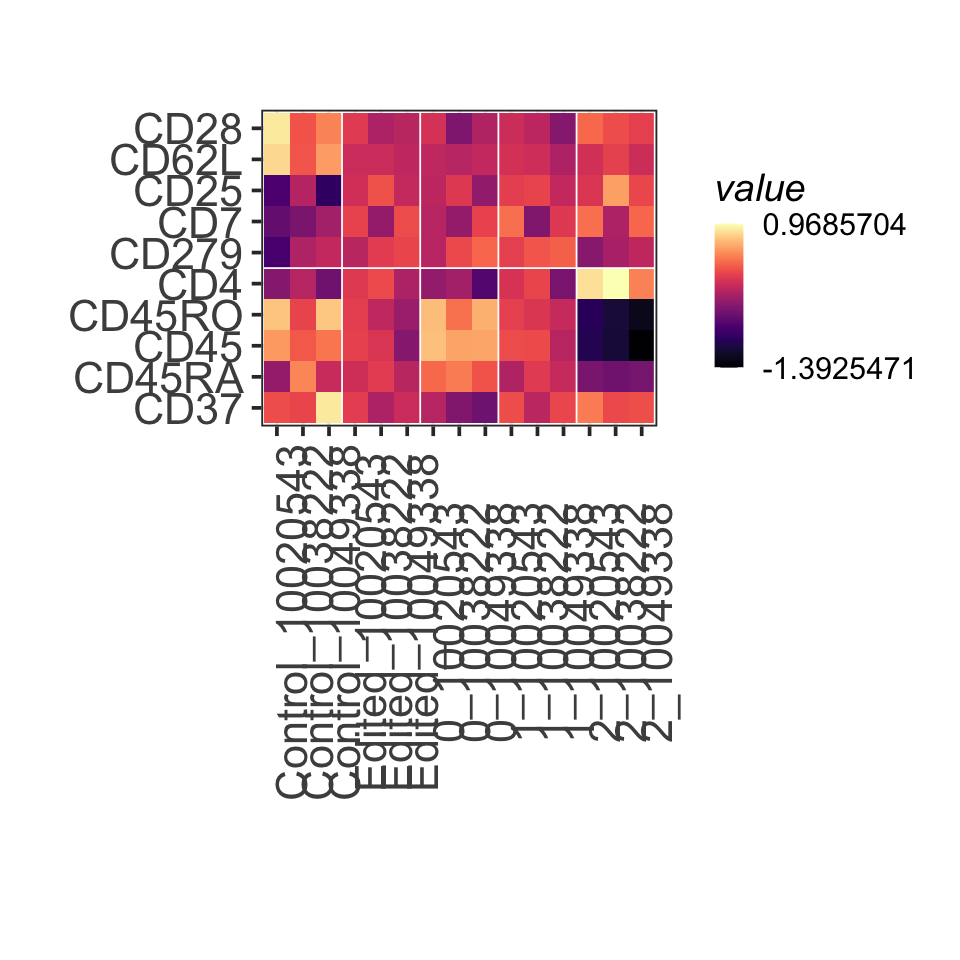

In [635]:
fig.size(8,8)
g <-  ggplot() + 
geom_tile(data = df_adt,
          aes(x = X, y = gene, fill = value)) + 
geom_tile(data = df2_adt,
          aes(x = X, y = gene, fill = value)) + 
scale_fill_viridis(option = "magma", breaks = c(max(df_adt$value, df2_adt$value), min(df_adt$value, df2_adt$value))) + 
theme_gy() + 
scale_y_discrete(limits = c(order_adt)) + 
theme(axis.text.x = element_text(angle = 90)) + 
scale_x_discrete(limits = c(unique(df2_adt$X),unique(df_adt$X))) + 
geom_vline(xintercept = c(3.5, 6.5, 9.5,12.5,15.5), color = "white")+
geom_hline(yintercept = 5.5, color = "white") + 
xlab("") + ylab("") +
  theme(legend.position = "right") + 
theme(aspect.ratio = 0.8)

plot(g)
## save the plot
suppressWarnings({ 
    ggsave(g, filename = "g.png", device = "png", dpi = 300)
    })

## Random Plots

In [ ]:
## Layer these together as was done in the past with FBXO11

In [134]:
CD45Plots3 <- CD45Plots3 %>% mutate(genotype3 = ifelse(Edited_Index == "Edited" & Dosage == 0, "C", 
                                        ifelse(Edited_Index == "Edited" & Dosage == 1, "C/T", 
                                              ifelse(Edited_Index == "Edited" & Dosage == 2, "T", "Control"))))

In [648]:
CD45_lm_Dosage %>% arrange(padjBH)

gene,(Intercept),log10(nUMI.y),PlateP3,PlateP4,Individual_Index10038222,Individual_Index10049338,Dosage,pval,padjBH
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PTPRC,-9.118225,2.445656,0.28734860,0.193869496,-0.224154408,-0.256680657,-0.6525851,5.551115e-16,3.059220e-12
ANXA3,-13.432073,2.556328,0.28211425,0.027903927,0.904010858,0.343280105,0.8785004,2.275742e-08,6.270806e-05
TNFRSF4,-4.197007,1.976669,0.05295609,0.143732884,-0.177954145,0.098516208,-0.2730704,2.585736e-06,3.562498e-03
CHCHD10,-10.604930,2.744217,-0.15127065,0.075360014,-0.271793591,-0.001834315,0.3580782,2.263081e-06,3.562498e-03
TRBC2,-6.128260,2.293284,0.20030552,0.109675976,-0.402805685,-0.068585180,-0.2459947,2.601048e-05,2.866875e-02
MT-ND4,-4.341429,2.057043,0.29092294,0.266618460,-0.125264976,-0.011789315,0.1090024,8.726023e-05,6.738981e-02
PSMB6,-9.941476,2.696614,-0.12641378,-0.081808743,-0.073650188,-0.087299237,0.1842270,2.009324e-04,6.738981e-02
PSMA5,-10.324493,2.732694,0.14711876,-0.216517904,0.107649241,-0.123135620,0.1998966,1.902351e-04,6.738981e-02
CDKAL1,-6.430931,1.487292,-0.36181936,-0.081107860,-0.109535024,-0.149485929,0.2617270,1.132222e-04,6.738981e-02


In [698]:
norm_adt <- counts_ADT_filt_CD45 %>% singlecellmethods::normalizeData(method = "cellCLR")

Joining with `by = join_by(cell)`


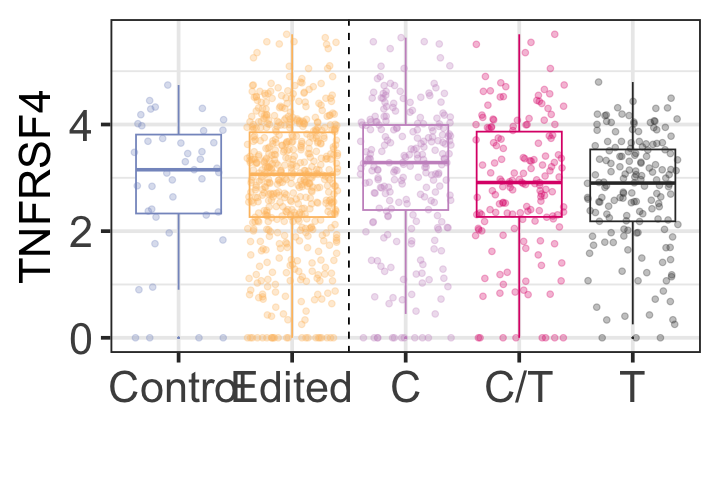

In [137]:
fig.size(4, 6)

norm_exprs["TNFRSF4",] %>% as_tibble(rownames = "cell") %>% inner_join(CD45Plots3) %>%  
    filter(genotype_count >2) %>% na.omit() %>%
{

ggplot(.) +  
geom_boxplot(data = ., outlier.size = 0,
             aes(Edited_Index, `value`, color = Edited_Index)) + 
geom_boxplot(outlier.size = 0, 
             data = . %>% filter(Edited_Index != "Control"),
             aes((genotype3), `value`, color = as.factor(genotype3))) +
geom_jitter(aes(Edited_Index, `value`, color = Edited_Index), 
           alpha = 0.3) + 
geom_jitter(data = . %>% filter(Edited_Index != "Control"),
             aes((genotype3), `value`, color = as.factor(genotype3)), 
           alpha = 0.3) + 
theme_gy()+
scale_x_discrete(limits = c("Control", 
                           "Edited", 
                           "C",
                           "C/T", 
                           "T"
                           )) + 
geom_vline(xintercept = 2.5, linetype = 2) + 
scale_color_manual(values = c(
          "Control" = "#8698C7",
          "Edited" = "#FDBF6E",
          "C" = "#C994C7",
          "C/T" = "#DD1C77", 
          "T" = "grey20"))+ 
xlab("") + 
ylab("TNFRSF4")+ 
theme(
     # axis.title.y = element_text(face = "italic"),
    legend.position = "none")
    
    }

Joining with `by = join_by(cell)`


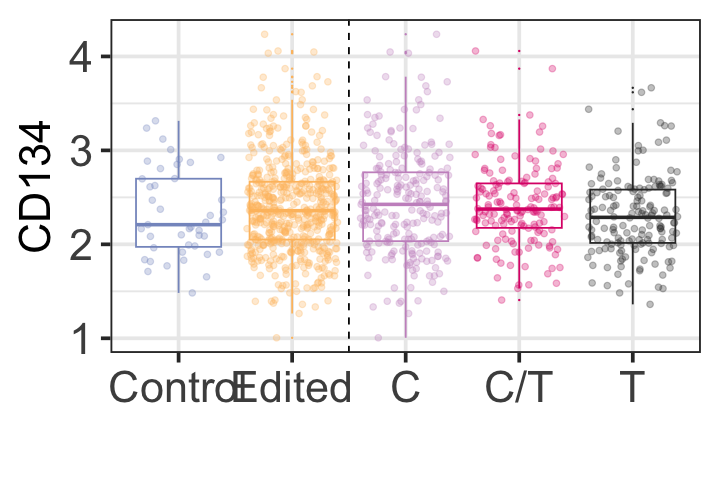

In [138]:
fig.size(4, 6)

norm_adt["CD134",] %>% as_tibble(rownames = "cell") %>% inner_join(CD45Plots3) %>%  
    filter(genotype_count >2) %>% na.omit() %>%
{

ggplot(.) +  
geom_boxplot(data = ., outlier.size = 0,
             aes(Edited_Index, `value`, color = Edited_Index)) + 
geom_boxplot(outlier.size = 0, 
             data = . %>% filter(Edited_Index != "Control"),
             aes((genotype3), `value`, color = as.factor(genotype3))) +
geom_jitter(aes(Edited_Index, `value`, color = Edited_Index), 
           alpha = 0.3) + 
geom_jitter(data = . %>% filter(Edited_Index != "Control"),
             aes((genotype3), `value`, color = as.factor(genotype3)), 
           alpha = 0.3) + 
theme_gy()+
scale_x_discrete(limits = c("Control", 
                           "Edited", 
                           "C",
                           "C/T", 
                           "T"
                           )) + 
geom_vline(xintercept = 2.5, linetype = 2) + 
scale_color_manual(values = c(
          "Control" = "#8698C7",
          "Edited" = "#FDBF6E",
          "C" = "#C994C7",
          "C/T" = "#DD1C77", 
          "T" = "grey20"))+ 
xlab("") + 
ylab("CD134")+ 
theme(
     # axis.title.y = element_text(face = "italic"),
    legend.position = "none")
    
    }

Joining with `by = join_by(cell)`


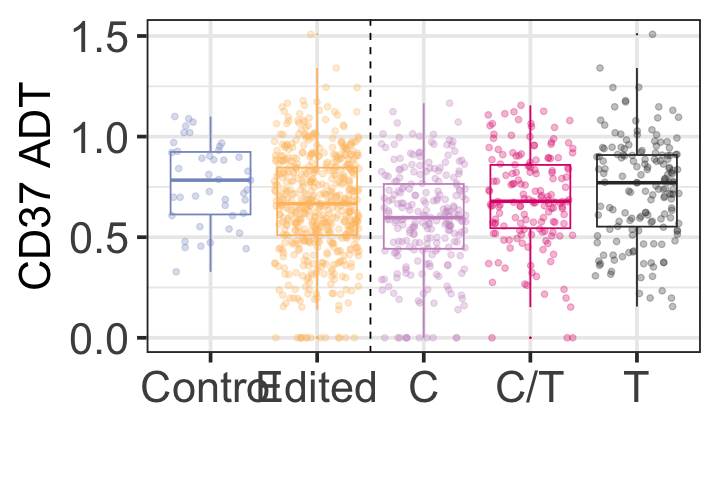

In [140]:
fig.size(4, 6)

norm_adt["CD37",] %>% as_tibble(rownames = "cell") %>% inner_join(CD45Plots3) %>%  
    filter(genotype_count >2) %>% na.omit() %>%
{

ggplot(.) +  
geom_boxplot(outlier.size = 0,
             aes(Edited_Index, `value`, color = Edited_Index)) + 
geom_boxplot(outlier.size = 0, 
             data = . %>% filter(genotype3 != "Control"),
             aes(genotype3, `value`, color = genotype3)) +
geom_jitter(aes(Edited_Index, `value`, color = Edited_Index), 
           alpha = 0.3) + 
geom_jitter(data = . %>% filter(genotype3 != "Control"),
             aes(genotype3, `value`, color = genotype3), 
           alpha = 0.3) + 
theme_gy()+
scale_x_discrete(limits = c("Control", 
                           "Edited", 
                           "C",
                           "C/T", 
                           "T"
                           )) + 
geom_vline(xintercept = 2.5, linetype = 2) + 
scale_color_manual(values = c(
          "Control" = "#8698C7",
          "Edited" = "#FDBF6E",
          "C" = "#C994C7",
          "C/T" = "#DD1C77", 
          "T" = "grey20"))+ 
xlab("") + 
ylab("CD37 ADT")+ 
theme(
     # axis.title.y = element_text(face = "italic"),
    legend.position = "none") 
    
} 

## Volacano Plots

In [84]:
CD45_lm_Dosage %>% head

gene,(Intercept),log10(nUMI.y),PlateP3,PlateP4,Individual_Index10038222,Individual_Index10049338,Dosage,pval,padjBH
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MT-CO2,-3.5006194,2.130221,-0.1382712,0.01895425,-0.16224820,-0.03200045,0.06022700,0.0190552005,0.3968129
MALAT1,0.2594335,1.074377,-0.1108392,-0.01603064,-0.36429234,-0.05141699,-0.10926624,0.0063225546,0.2791995
TPI1,-6.4686060,2.699072,0.2413221,0.21555403,0.05884542,0.01123968,-0.03282912,0.1155115471,0.6810422
TMSB10,-2.4553364,1.660458,-0.6509961,-0.33865911,-0.05277669,0.07546562,0.04831342,0.0208905896,0.4044072
RPLP0,-4.7499869,2.397953,0.1657264,0.08608635,0.08904630,0.04023906,-0.01874479,0.3397473431,0.8293229
RPL10,-4.0642373,2.128046,-0.2702097,-0.15602620,-0.09286718,-0.04539214,-0.05280260,0.0008819483,0.1430838


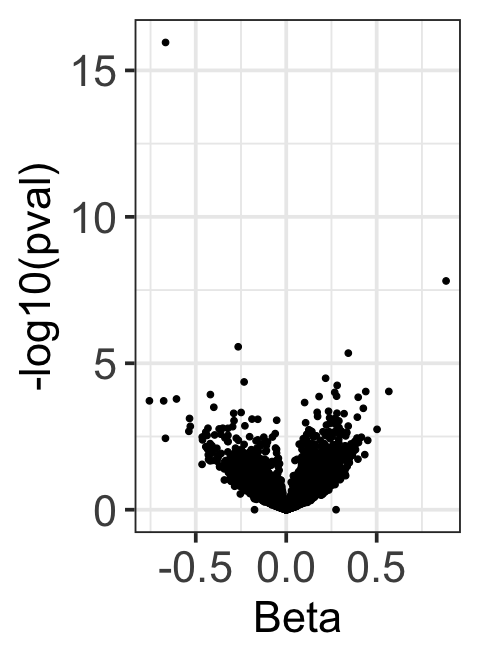

In [90]:
fig.size(5.5)
CD45_lm_Dosage %>% { 
    ggplot(., aes(Dosage, -log10(pval))) + geom_point() } + theme_gy() + xlab("Beta")

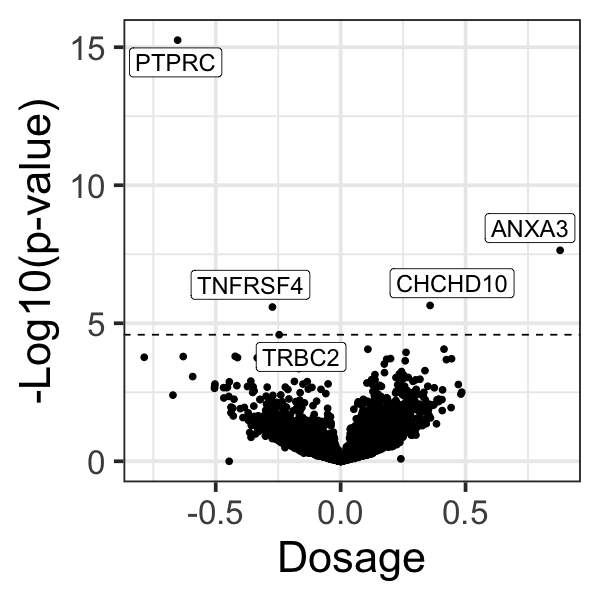

In [645]:
fig.size(5,5)
g <- CD45_lm_Dosage %>% {
ggplot(.) + 
geom_point(aes(Dosage, -log10(pval))) +
theme_gy() +
geom_label_repel(data = . %>% filter(padjBH < 0.05), 
               aes(Dosage, -log10(pval), label = gene), size = 5) + 
theme(legend.position = "none") + 
geom_hline(yintercept = -log10(CD45_lm_Dosage %>% arrange(pval) %>% filter(padjBH < 0.05) %>% tail(1) %>% with(pval)), linetype =2)+ 
ylab("-Log10(p-value)") +
    theme(axis.text.x = element_text(size = 20),
          axis.text.y = element_text(size = 20),
          strip.text = element_blank(), 
         panel.spacing = unit(1, "lines"))

}
g

In [112]:
ggsave(g, filename = "g.png", device = "png", width = 5, height = 5)

Warning message:
“ggrepel: 17 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


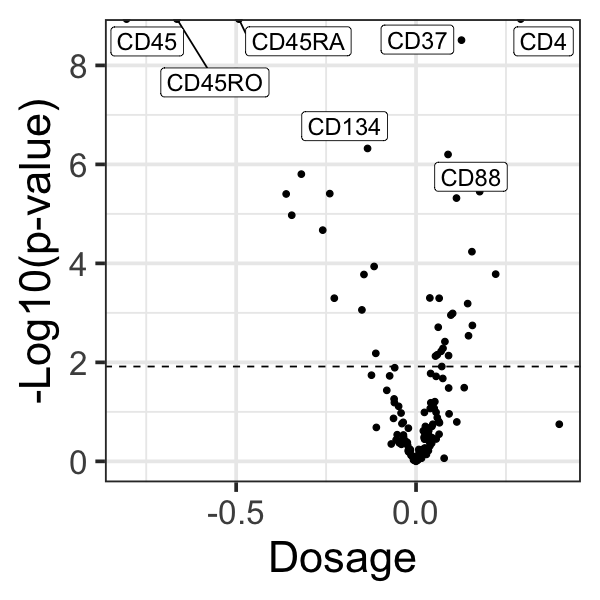

In [817]:
fig.size(5,5)
g <- CD45_lm_Dosage_adt %>% {
ggplot(.) + 
geom_point(aes(Dosage, -log10(pval))) +
theme_gy() +
geom_label_repel(data = . %>% filter(pval < 10^-6), 
               aes(Dosage, -log10(pval), label = gene), size = 5) + 
theme(legend.position = "none") + 
geom_hline(yintercept = -log10(CD45_lm_Dosage_adt %>% arrange(pval) %>% filter(padjBH < 0.05) %>% tail(1) %>% with(pval)), linetype =2)+ 
ylab("-Log10(p-value)") +
    theme(axis.text.x = element_text(size = 20),
          axis.text.y = element_text(size = 20),
          strip.text = element_blank(), 
         panel.spacing = unit(1, "lines"))

}
g